<a href="https://colab.research.google.com/github/danangcorp/Electricity-Consumption-Prediction/blob/main/Prediksi_Konsumsi_Listrik_Bulanan_Rumah_Tangga_Menggunakan_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Prediksi Konsumsi Listrik Bulanan Rumah Tangga Menggunakan Machine Learning

## **1. Business Understanding**
##1.1 Latar Belakang

Konsumsi listrik rumah tangga dipengaruhi oleh berbagai faktor, seperti luas rumah, jumlah anggota keluarga, jumlah perangkat elektronik, kondisi cuaca, hingga tingkat okupansi rumah. Prediksi konsumsi listrik dapat membantu rumah tangga maupun penyedia layanan listrik dalam melakukan perencanaan penggunaan energi secara lebih efisien.

##1.2 Permasalahan
Sulit memperkirakan konsumsi listrik bulanan hanya berdasarkan perkiraan pengguna.
Banyak faktor yang memengaruhi penggunaan listrik sehingga diperlukan pendekatan berbasis data.
Dibutuhkan model prediksi yang mampu memberikan estimasi konsumsi listrik secara akurat.
##1.3 Tujuan Penelitian

Membangun model machine learning untuk memprediksi konsumsi listrik bulanan rumah tangga berdasarkan karakteristik rumah dan pola penggunaan listrik.

##1.4 Tujuan Data Mining

Menghasilkan model regresi yang mampu memprediksi nilai Monthly Electricity Consumption dengan tingkat kesalahan serendah mungkin.

##1.5 Success Criteria

Model dievaluasi menggunakan:

Mean Absolute Error (MAE)
Mean Squared Error (MSE)
Root Mean Squared Error (RMSE)
R² Score

#2. Data Understanding

##1. Import Library

In [1]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##2. Load Dataset

In [2]:
# Membaca dataset
df = pd.read_excel('/content/dirty_electricity_consumption_dataset.xlsx')

# Menampilkan 5 data pertama
df.head()

,House_ID,House_Type,Family_Members,House_Area_sqft,Air_Conditioners,Refrigerators,Washing_Machines,Televisions,Computers,Water_Heaters,Ceiling_Fans,LED_Lights,EV_Charger,Solar_Panels,Daily_Usage_Hours,Average_Temperature,Season,Occupancy_Rate,Electricity_Tariff,Monthly_Electricity_Consumption
0,3313.0,Apartment,2.0,945.0,2.0,2.0,1.0,4.0,1.0,0.0,5.0,18.0,No,No,14.8,NaN,Summer,60.0,9.16,1399.00
1,17846.0,Independent,6.0,2959.0,1.0,1.0,2.0,4.0,3.0,2.0,2.0,7.0,No,Yes,9.5,26.4,Winter,93.0,5.26,1310.97
2,7106.0,Villa,6.0,1265.0,4.0,2.0,2.0,200.0,2.0,3.0,-30.0,14.0,No,No,8.1,33.6,Summer,55.0,6.91,1806.31
3,19083.0,Independent,7.0,2281.0,2.0,3.0,1.0,3.0,0.0,2.0,8.0,38.0,Yes,No,NaN,25.9,Winter,65.0,6.66,NaN
4,12336.0,Independent,1.0,857.0,1.0,3.0,1.0,4.0,3.0,0.0,8.0,8.0,No,Yes,14.7,37.1,NaN,80.0,7.49,1222.93


In [3]:
# Menampilkan 5 data terakhir
df.tail()

,House_ID,House_Type,Family_Members,House_Area_sqft,Air_Conditioners,Refrigerators,Washing_Machines,Televisions,Computers,Water_Heaters,Ceiling_Fans,LED_Lights,EV_Charger,Solar_Panels,Daily_Usage_Hours,Average_Temperature,Season,Occupancy_Rate,Electricity_Tariff,Monthly_Electricity_Consumption
20995,12285.0,Villa,1.0,548.0,NaN,1.0,2.0,3.0,0.0,2.0,7.0,6.0,No,No,12.5,31.9,Rainy,80.0,7.30,1207.68
20996,12965.0,Apartment,NaN,577.0,2.0,3.0,1.0,2.0,3.0,0.0,3.0,35.0,No,Yes,23.8,19.3,Winter,42.0,8.57,1270.59
20997,6391.0,Villa,2.0,4028.0,1.0,2.0,1.0,2.0,0.0,2.0,7.0,27.0,Yes,Yes,21.4,31.2,Rainy,66.0,8.04,1594.42
20998,1861.0,Independent,NaN,4442.0,0.0,3.0,2.0,4.0,0.0,2.0,3.0,20.0,No,No,11.8,36.5,Summer,99.0,7.58,1640.87
20999,16796.0,Apartment,8.0,2904.0,2.0,1.0,NaN,4.0,2.0,0.0,5.0,18.0,No,Yes,13.9,31.3,Summer,56.0,NaN,1523.04


##3. Memahami Struktur Dataset

In [4]:
# Menampilkan jumlah baris dan kolom
df.shape

(21000, 20)

In [5]:
# Menampilkan informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   House_ID                         19969 non-null  float64
 1   House_Type                       19952 non-null  object 
 2   Family_Members                   19928 non-null  float64
 3   House_Area_sqft                  19979 non-null  float64
 4   Air_Conditioners                 19952 non-null  float64
 5   Refrigerators                    19952 non-null  float64
 6   Washing_Machines                 19964 non-null  float64
 7   Televisions                      20030 non-null  float64
 8   Computers                        19926 non-null  float64
 9   Water_Heaters                    19995 non-null  float64
 10  Ceiling_Fans                     19957 non-null  float64
 11  LED_Lights                       19960 non-null  float64
 12  EV_Charger        

In [6]:
# Menampilkan nama seluruh kolom
df.columns

Index(['House_ID', 'House_Type', 'Family_Members', 'House_Area_sqft',
       'Air_Conditioners', 'Refrigerators', 'Washing_Machines', 'Televisions',
       'Computers', 'Water_Heaters', 'Ceiling_Fans', 'LED_Lights',
       'EV_Charger', 'Solar_Panels', 'Daily_Usage_Hours',
       'Average_Temperature', 'Season', 'Occupancy_Rate', 'Electricity_Tariff',
       'Monthly_Electricity_Consumption'],
      dtype='object')

##4. Deskripsi Variabel

In [7]:
# Membuat tabel deskripsi variabel
deskripsi_variabel = pd.DataFrame({
    'Variabel': [
        'House_ID',
        'House_Type',
        'Family_Members',
        'House_Area_sqft',
        'Air_Conditioners',
        'Refrigerators',
        'Washing_Machines',
        'Televisions',
        'Computers',
        'Water_Heaters',
        'Ceiling_Fans',
        'LED_Lights',
        'EV_Charger',
        'Solar_Panels',
        'Daily_Usage_Hours',
        'Average_Temperature',
        'Season',
        'Occupancy_Rate',
        'Electricity_Tariff',
        'Monthly_Electricity_Consumption'
    ],

    'Deskripsi': [
        'ID unik setiap rumah',
        'Jenis rumah',
        'Jumlah anggota keluarga',
        'Luas rumah (sqft)',
        'Jumlah AC',
        'Jumlah kulkas',
        'Jumlah mesin cuci',
        'Jumlah televisi',
        'Jumlah komputer/laptop',
        'Jumlah pemanas air',
        'Jumlah kipas angin plafon',
        'Jumlah lampu LED',
        'Ketersediaan charger kendaraan listrik',
        'Ketersediaan panel surya',
        'Rata-rata lama penggunaan listrik per hari (jam)',
        'Suhu rata-rata lingkungan',
        'Musim',
        'Persentase tingkat hunian rumah',
        'Tarif listrik per satuan',
        'Konsumsi listrik bulanan (Target)'
    ]
})

deskripsi_variabel

,Variabel,Deskripsi
0,House_ID,ID unik setiap rumah
1,House_Type,Jenis rumah
2,Family_Members,Jumlah anggota keluarga
3,House_Area_sqft,Luas rumah (sqft)
4,Air_Conditioners,Jumlah AC
5,Refrigerators,Jumlah kulkas
6,Washing_Machines,Jumlah mesin cuci
7,Televisions,Jumlah televisi
8,Computers,Jumlah komputer/laptop
9,Water_Heaters,Jumlah pemanas air


##5. Missing Value

In [8]:
# Mengecek jumlah missing value pada setiap kolom
df.isnull().sum()

,0
House_ID,1031
House_Type,1048
Family_Members,1072
House_Area_sqft,1021
Air_Conditioners,1048
Refrigerators,1048
Washing_Machines,1036
Televisions,970
Computers,1074
Water_Heaters,1005


In [9]:
# Menghitung persentase missing value
missing = pd.DataFrame({
    'Jumlah Missing': df.isnull().sum(),
    'Persentase (%)': (df.isnull().sum() / len(df)) * 100
})

missing

,Jumlah Missing,Persentase (%)
House_ID,1031,4.909524
House_Type,1048,4.990476
Family_Members,1072,5.104762
House_Area_sqft,1021,4.861905
Air_Conditioners,1048,4.990476
Refrigerators,1048,4.990476
Washing_Machines,1036,4.933333
Televisions,970,4.619048
Computers,1074,5.114286
Water_Heaters,1005,4.785714


In [10]:
# Menampilkan hanya kolom yang memiliki missing value
missing[missing['Jumlah Missing'] > 0]

,Jumlah Missing,Persentase (%)
House_ID,1031,4.909524
House_Type,1048,4.990476
Family_Members,1072,5.104762
House_Area_sqft,1021,4.861905
Air_Conditioners,1048,4.990476
Refrigerators,1048,4.990476
Washing_Machines,1036,4.933333
Televisions,970,4.619048
Computers,1074,5.114286
Water_Heaters,1005,4.785714


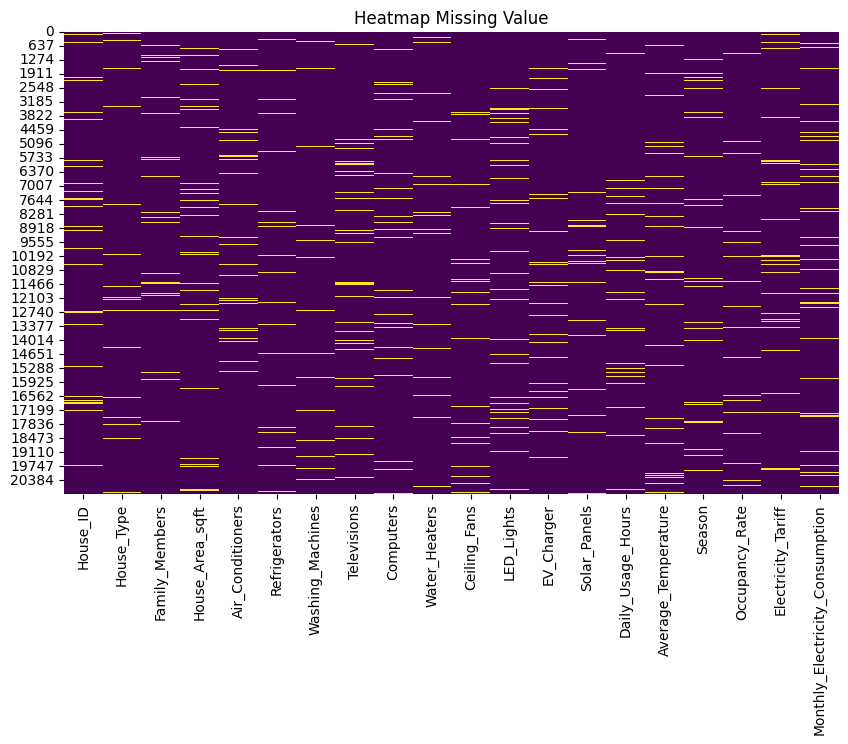

In [11]:
# Visualisasi missing value
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title('Heatmap Missing Value')
plt.show()

##6. Duplicate Data

In [12]:
# Mengecek jumlah data duplikat
df.duplicated().sum()

np.int64(1000)

##7. Statistik Deskriptif

In [13]:
# Statistik deskriptif variabel numerik
print(df.describe())

           House_ID  Family_Members  House_Area_sqft  Air_Conditioners  \
count  1.996900e+04    19928.000000     19979.000000      19952.000000   
mean   3.475956e+04       13.755921      3294.420091          1.317763   
std    1.807380e+05       72.439538      6920.743609          3.371367   
min    1.001000e+03        1.000000       500.000000        -40.000000   
25%    6.109000e+03        3.000000      1515.000000          0.000000   
50%    1.121900e+04        5.000000      2532.000000          2.000000   
75%    1.634100e+04        7.000000      3551.500000          3.000000   
max    2.098300e+06      800.000000     90000.000000          4.000000   

       Refrigerators  Washing_Machines   Televisions     Computers  \
count   19952.000000      19964.000000  20030.000000  19926.000000   
mean        3.939906          0.796183      4.712781      4.020225   
std        14.765368          1.980844     18.055031     17.154020   
min         1.000000        -20.000000      1.000000 

In [14]:
# Statistik deskriptif variabel kategorikal
df.describe(include='object')

,House_Type,EV_Charger,Solar_Panels,Season
count,19952,19991,19994,19994
unique,3,2,2,3
top,Villa,Yes,Yes,Winter
freq,6704,10145,10029,6751


##8. Distribusi Target

##8.1 Histogram Distribusi Target

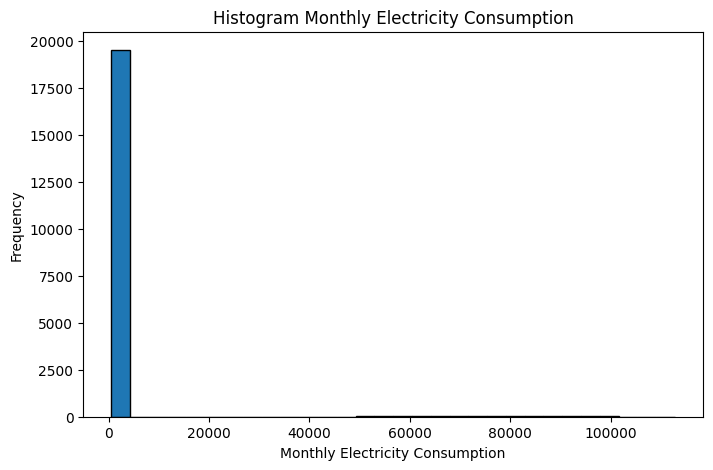

In [15]:
# Histogram distribusi Monthly_Electricity_Consumption
plt.figure(figsize=(8,5))
plt.hist(df['Monthly_Electricity_Consumption'], bins=30, edgecolor='black')

plt.title('Histogram Monthly Electricity Consumption')
plt.xlabel('Monthly Electricity Consumption')
plt.ylabel('Frequency')

plt.show()

##8.2 KDE Plot Distribusi Target

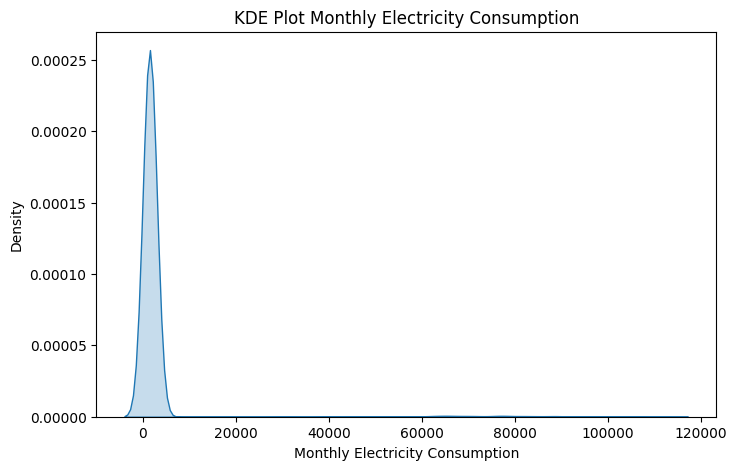

In [16]:
# KDE Plot distribusi target
plt.figure(figsize=(8,5))

sns.kdeplot(df['Monthly_Electricity_Consumption'], fill=True)

plt.title('KDE Plot Monthly Electricity Consumption')
plt.xlabel('Monthly Electricity Consumption')

plt.show()

##8.3 Boxplot Distribusi Target

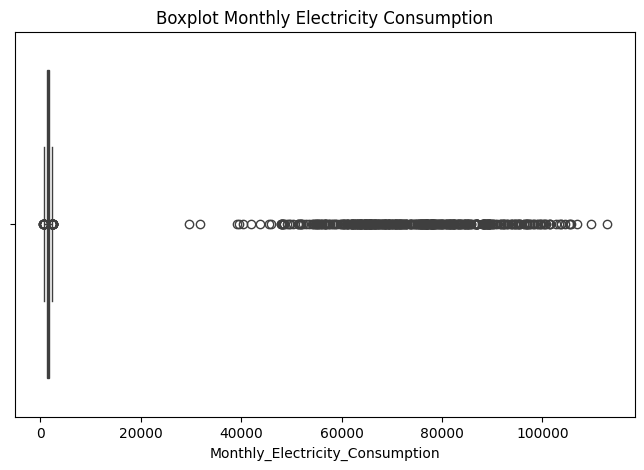

In [17]:
# Boxplot variabel target
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Monthly_Electricity_Consumption'])

plt.title('Boxplot Monthly Electricity Consumption')

plt.show()

##9. Analisis Variabel Numerik

##9.1 Menampilkan Histogram Seluruh Variabel Numerik

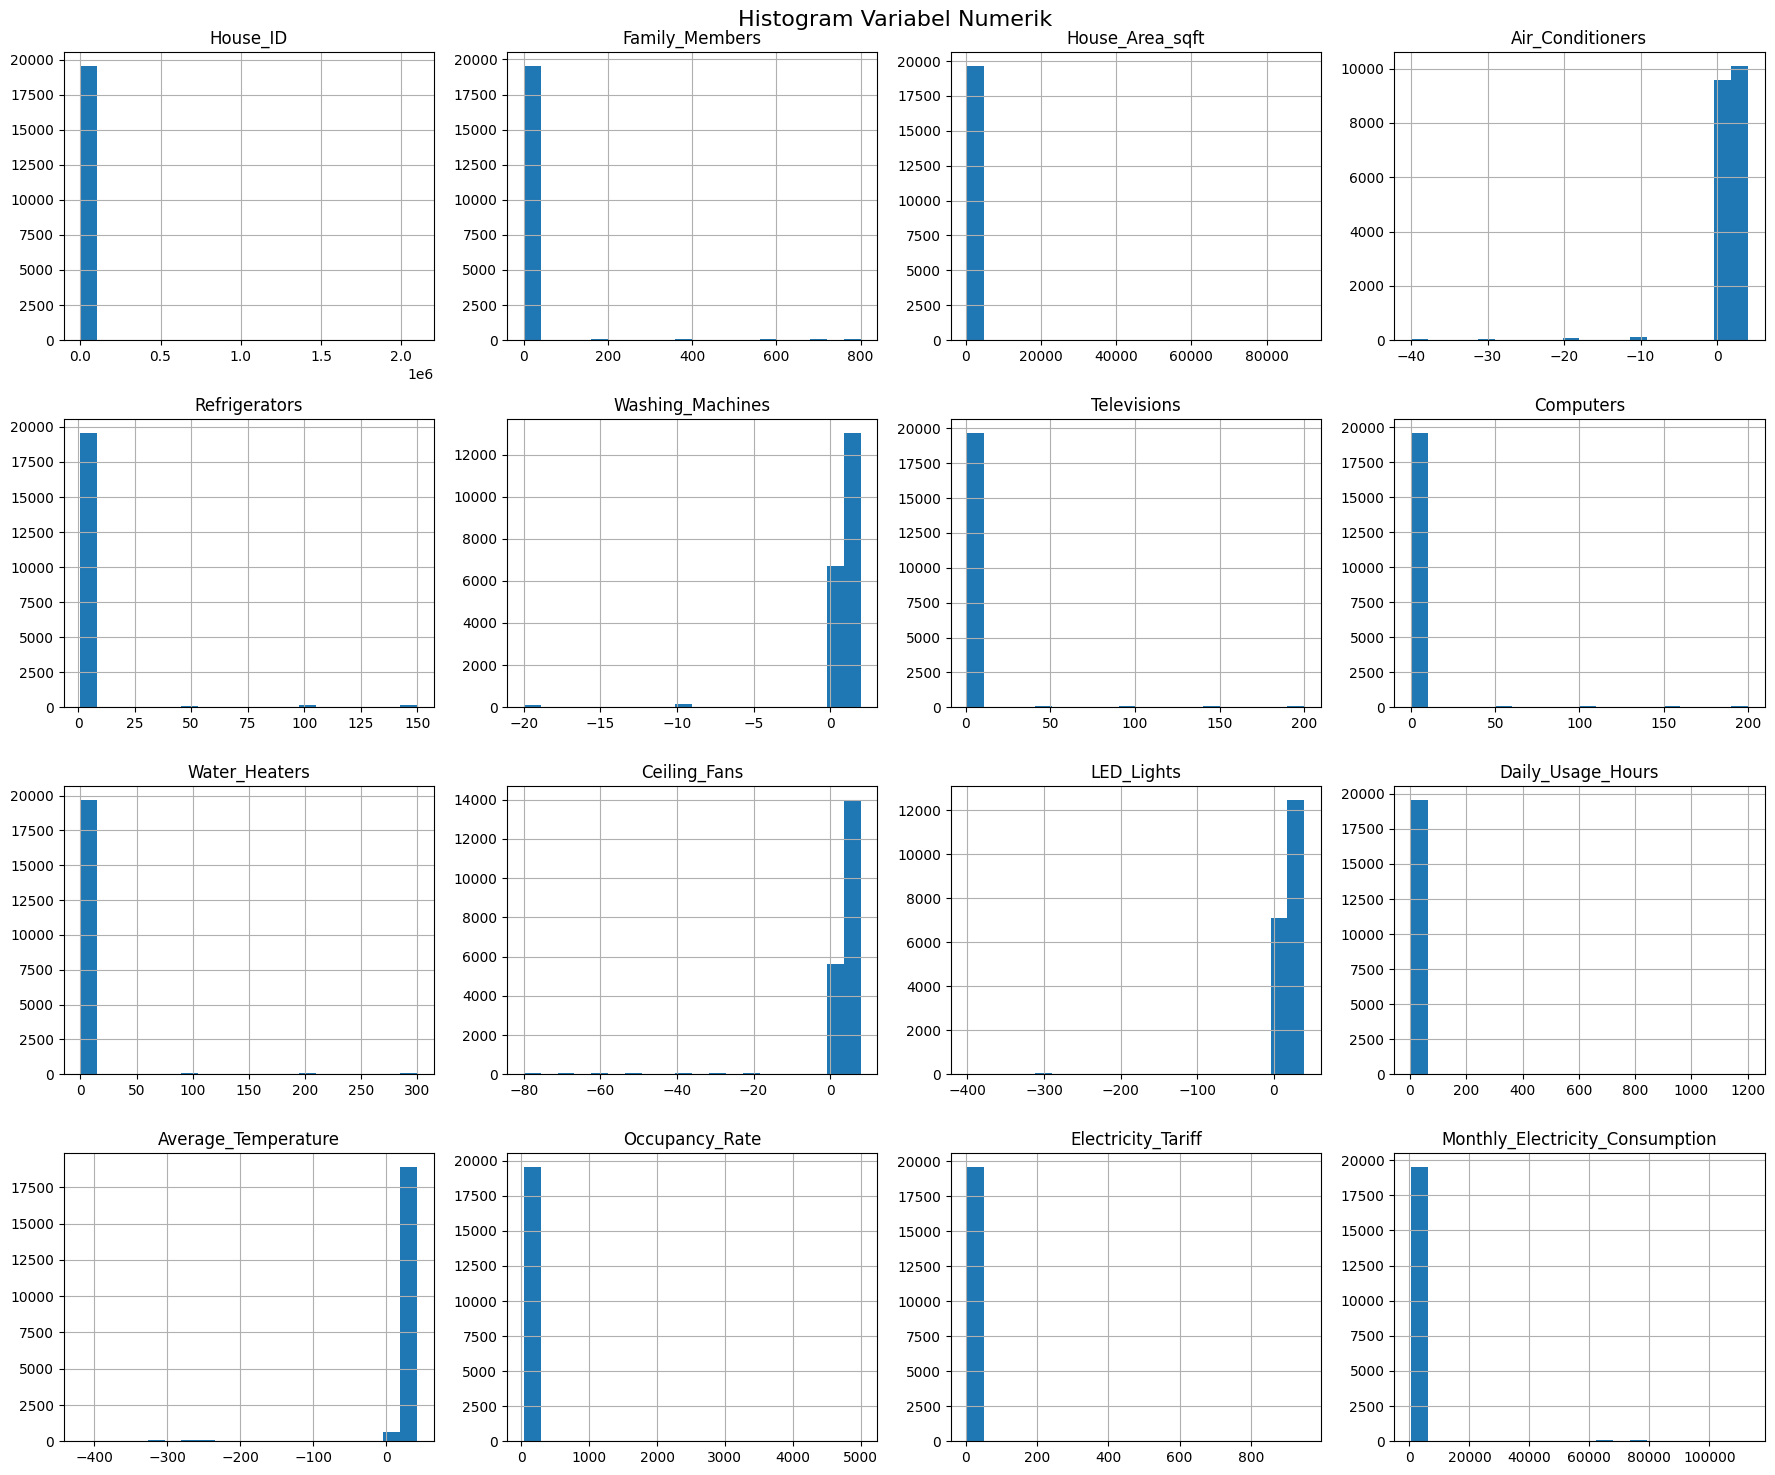

In [18]:
# Memilih variabel numerik
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Histogram seluruh variabel numerik
df[numerical_columns].hist(figsize=(18,15), bins=20)

plt.suptitle('Histogram Variabel Numerik', fontsize=16)
plt.tight_layout()

plt.show()

##9.2 Boxplot Seluruh Variabel Numerik

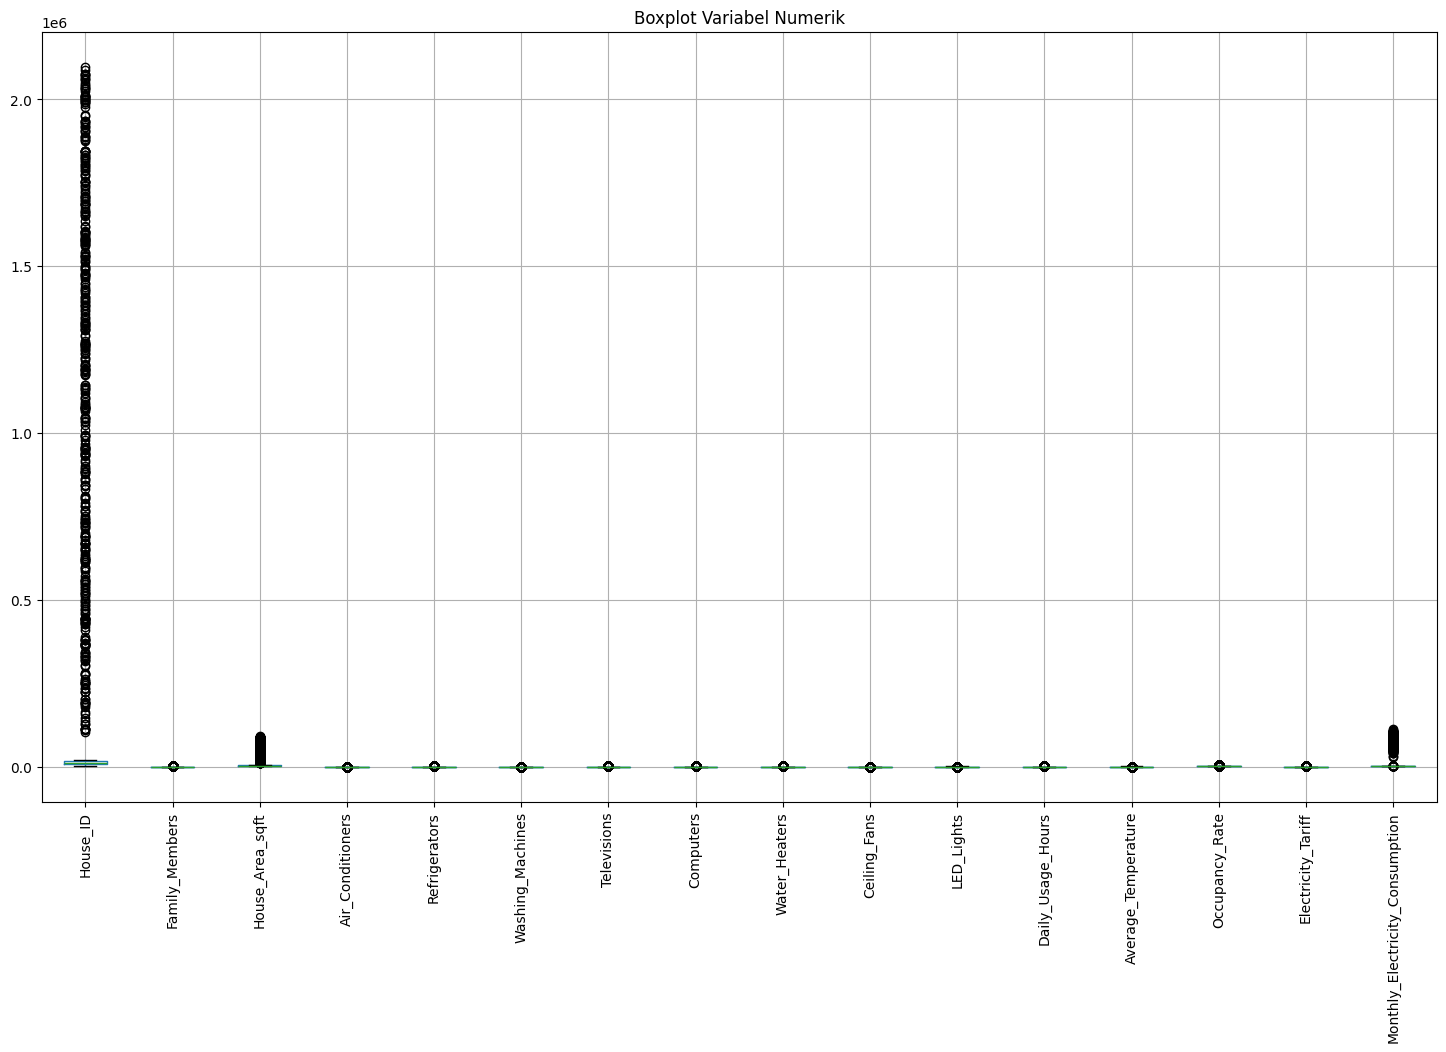

In [19]:
# Boxplot seluruh variabel numerik
plt.figure(figsize=(18,10))

df[numerical_columns].boxplot(rot=90)

plt.title('Boxplot Variabel Numerik')
plt.show()

##10. Analisis Variabel Kategorikal

In [20]:
# Menampilkan variabel kategorikal
categorical_columns = df.select_dtypes(include='object').columns
categorical_columns

Index(['House_Type', 'EV_Charger', 'Solar_Panels', 'Season'], dtype='object')

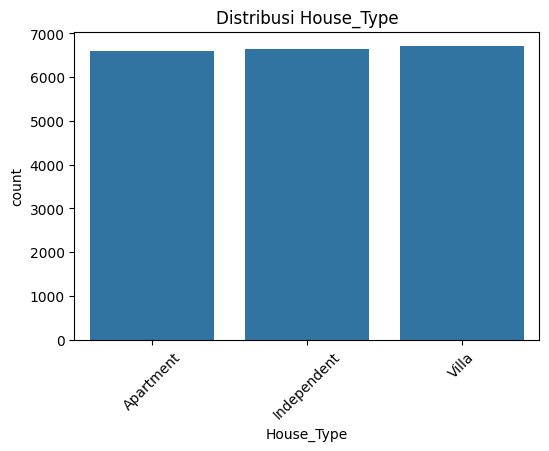

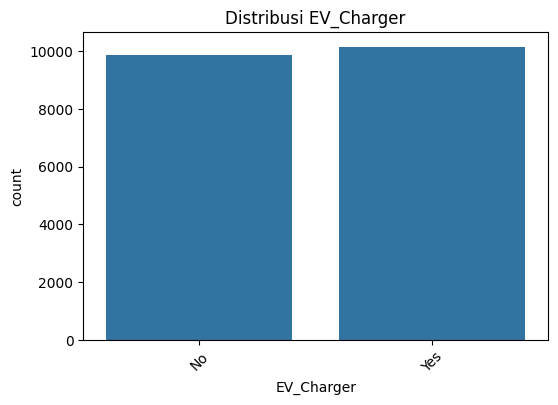

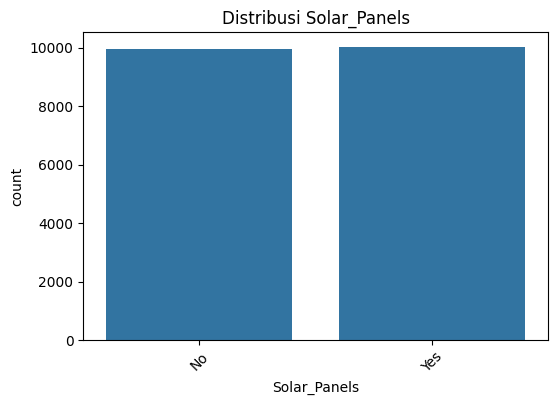

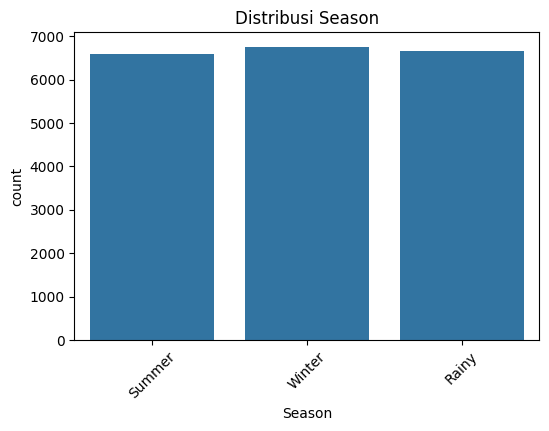

In [21]:
# Membuat countplot untuk setiap variabel kategorikal

for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)

    plt.title(f'Distribusi {col}')
    plt.xticks(rotation=45)

    plt.show()

##11. Korelasi

##11.1 Menghitung Korelasi

In [22]:
# Menghitung korelasi antar variabel numerik
correlation = df.corr(numeric_only=True)

correlation

,House_ID,Family_Members,House_Area_sqft,Air_Conditioners,Refrigerators,Washing_Machines,Televisions,Computers,Water_Heaters,Ceiling_Fans,LED_Lights,Daily_Usage_Hours,Average_Temperature,Occupancy_Rate,Electricity_Tariff,Monthly_Electricity_Consumption
House_ID,1.000000,-0.008748,-0.007847,-0.000970,0.005499,0.004769,0.006015,-0.013068,-0.002353,0.009800,-0.000953,-0.003792,-0.007752,0.005073,-0.000762,0.000749
Family_Members,-0.008748,1.000000,-0.012344,0.000378,-0.002520,-0.004986,-0.003327,0.008765,0.008319,0.000961,0.004396,-0.001340,-0.008663,0.000664,0.000650,-0.007575
House_Area_sqft,-0.007847,-0.012344,1.000000,0.001549,0.004328,-0.008365,-0.005483,-0.009380,0.026118,-0.004178,-0.002629,0.010748,0.004315,-0.010928,-0.012915,0.016409
Air_Conditioners,-0.000970,0.000378,0.001549,1.000000,0.005721,-0.003705,-0.024346,-0.005868,-0.000887,0.002351,0.001932,0.007413,-0.000664,0.001830,0.012445,0.008778
Refrigerators,0.005499,-0.002520,0.004328,0.005721,1.000000,-0.002355,-0.005752,-0.001496,-0.002499,-0.014647,-0.000432,-0.005665,-0.015839,-0.009332,0.004023,-0.004675
Washing_Machines,0.004769,-0.004986,-0.008365,-0.003705,-0.002355,1.000000,-0.012441,0.002653,-0.016633,0.004350,0.005183,-0.002782,0.000989,0.011065,0.006122,0.004194
Televisions,0.006015,-0.003327,-0.005483,-0.024346,-0.005752,-0.012441,1.000000,-0.001537,-0.002996,-0.003618,0.005360,-0.006621,-0.004422,-0.004493,0.014117,-0.008649
Computers,-0.013068,0.008765,-0.009380,-0.005868,-0.001496,0.002653,-0.001537,1.000000,-0.004721,-0.000063,0.005743,-0.001617,0.007739,-0.004793,-0.003422,-0.006411
Water_Heaters,-0.002353,0.008319,0.026118,-0.000887,-0.002499,-0.016633,-0.002996,-0.004721,1.000000,-0.008427,-0.004074,0.003015,0.007428,-0.003060,-0.002312,-0.001151
Ceiling_Fans,0.009800,0.000961,-0.004178,0.002351,-0.014647,0.004350,-0.003618,-0.000063,-0.008427,1.000000,-0.001266,0.001194,0.014281,-0.009099,0.012659,0.003870


##11.2 Heatmap Korelasi

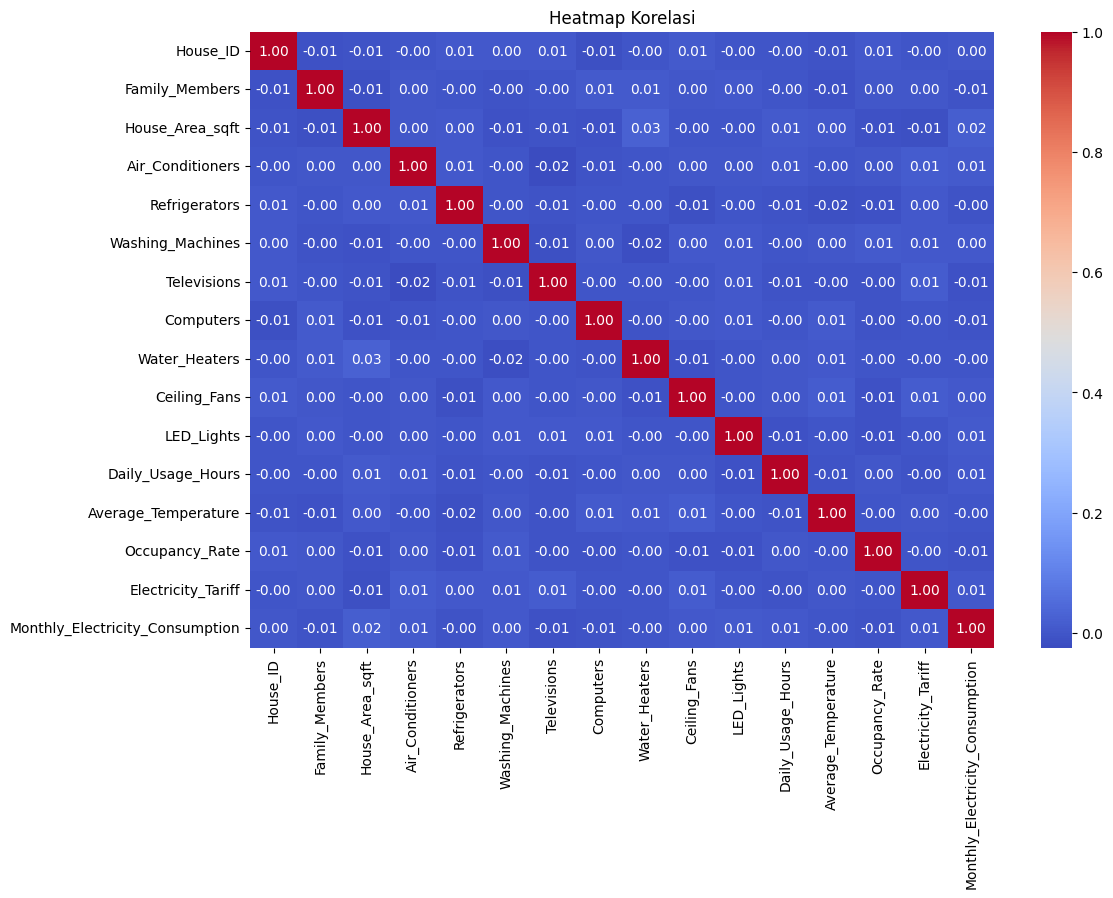

In [23]:
# Visualisasi heatmap korelasi
plt.figure(figsize=(12,8))

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Heatmap Korelasi')
plt.show()

##11.3 Korelasi terhadap Variabel Target

In [24]:
# Korelasi setiap fitur terhadap target
correlation['Monthly_Electricity_Consumption'].sort_values(ascending=False)

,Monthly_Electricity_Consumption
Monthly_Electricity_Consumption,1.000000
House_Area_sqft,0.016409
LED_Lights,0.009421
Air_Conditioners,0.008778
Electricity_Tariff,0.005909
Daily_Usage_Hours,0.005804
Washing_Machines,0.004194
Ceiling_Fans,0.003870
House_ID,0.000749
Average_Temperature,-0.000833


##12. Hubungan Fitur vs Target

##12.1 Scatter Plot

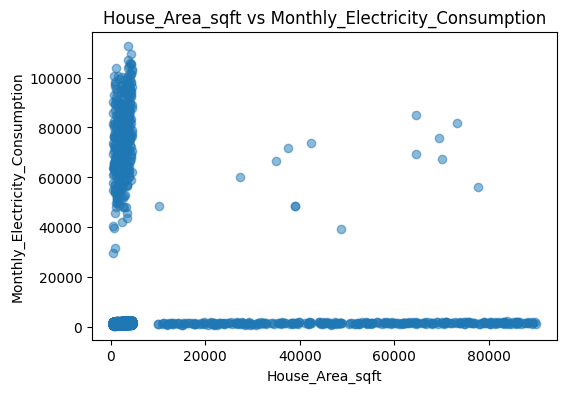

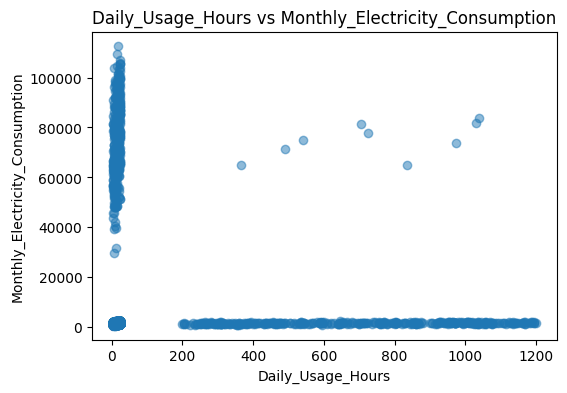

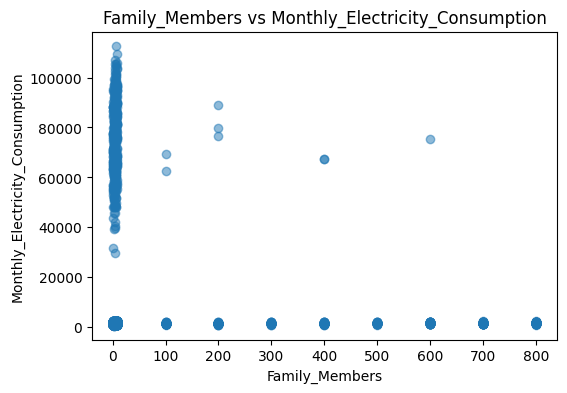

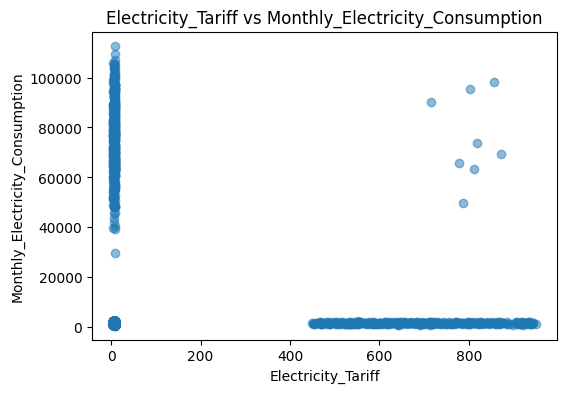

In [25]:
# Scatter plot beberapa fitur terhadap target

fitur = [
    'House_Area_sqft',
    'Daily_Usage_Hours',
    'Family_Members',
    'Electricity_Tariff'
]

for col in fitur:
    plt.figure(figsize=(6,4))

    plt.scatter(df[col], df['Monthly_Electricity_Consumption'], alpha=0.5)

    plt.title(f'{col} vs Monthly_Electricity_Consumption')
    plt.xlabel(col)
    plt.ylabel('Monthly_Electricity_Consumption')

    plt.show()

##12.2 Regression Plot

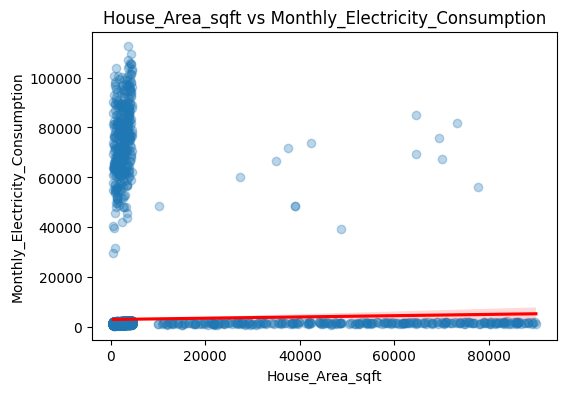

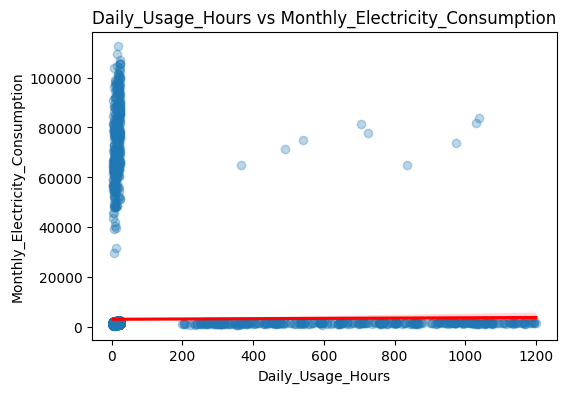

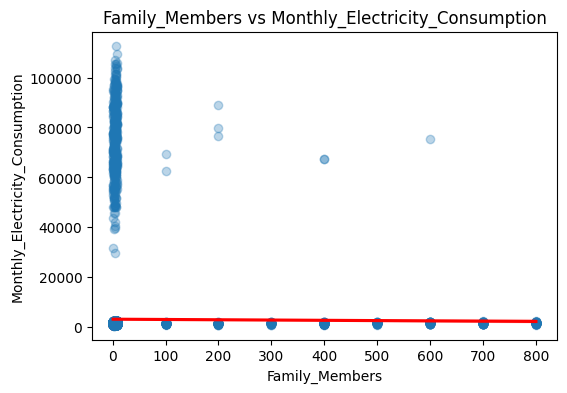

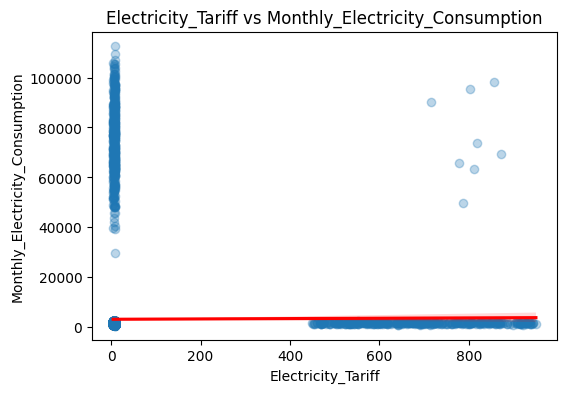

In [26]:
# Regression plot

for col in fitur:
    plt.figure(figsize=(6,4))

    sns.regplot(
        x=df[col],
        y=df['Monthly_Electricity_Consumption'],
        scatter_kws={'alpha':0.3},
        line_kws={'color':'red'}
    )

    plt.title(f'{col} vs Monthly_Electricity_Consumption')

    plt.show()

##13. Analisis Kategorikal vs Target

##13.1 Boxplot

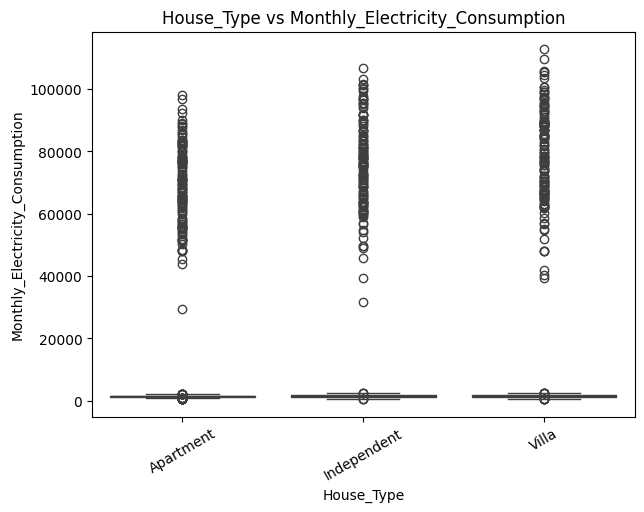

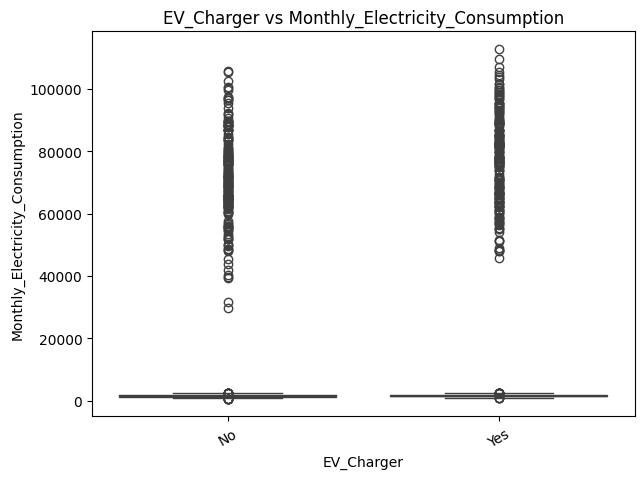

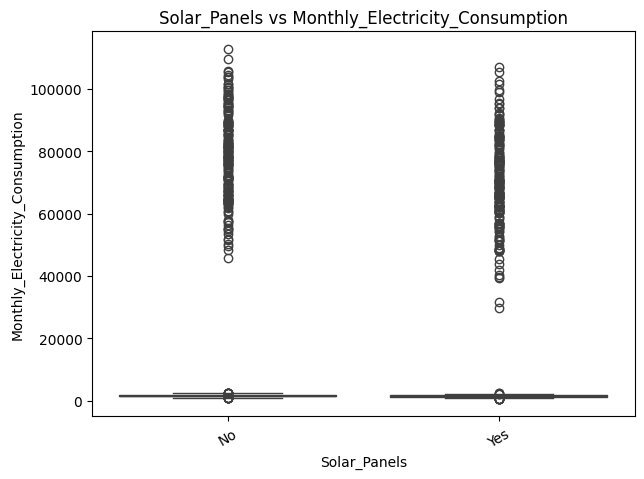

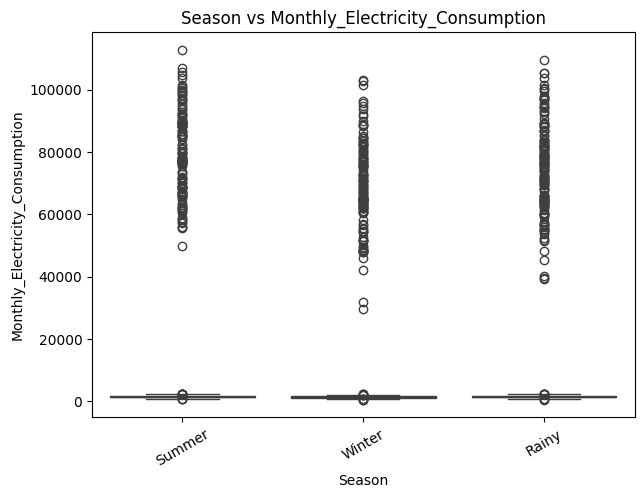

In [27]:
# Variabel kategorikal
categorical_columns = df.select_dtypes(include='object').columns

# Boxplot setiap variabel kategorikal terhadap target
for col in categorical_columns:
    plt.figure(figsize=(7,5))

    sns.boxplot(
        x=col,
        y='Monthly_Electricity_Consumption',
        data=df
    )

    plt.title(f'{col} vs Monthly_Electricity_Consumption')
    plt.xticks(rotation=30)

    plt.show()

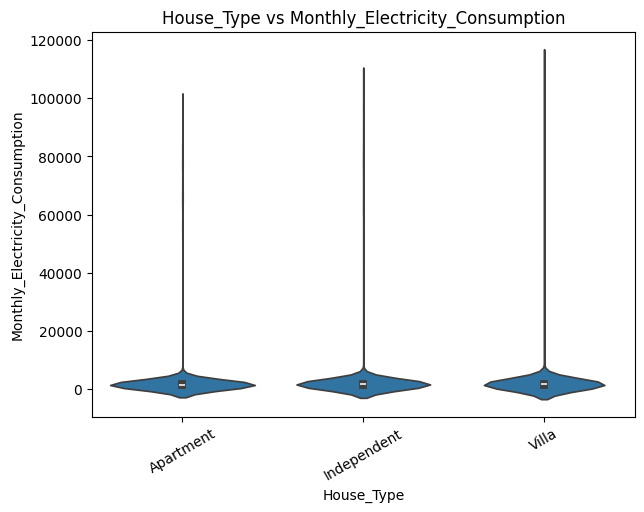

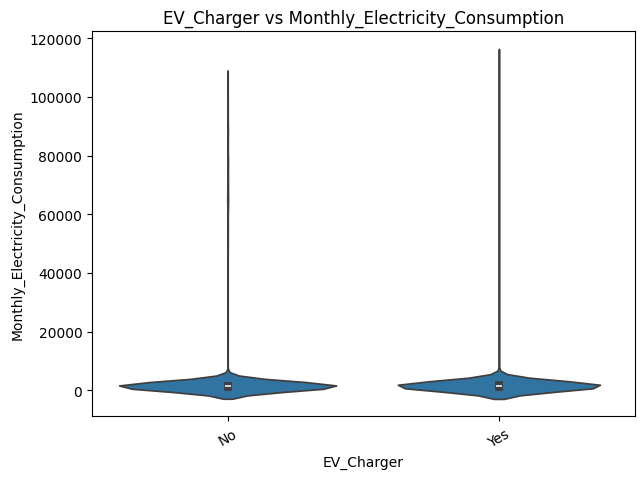

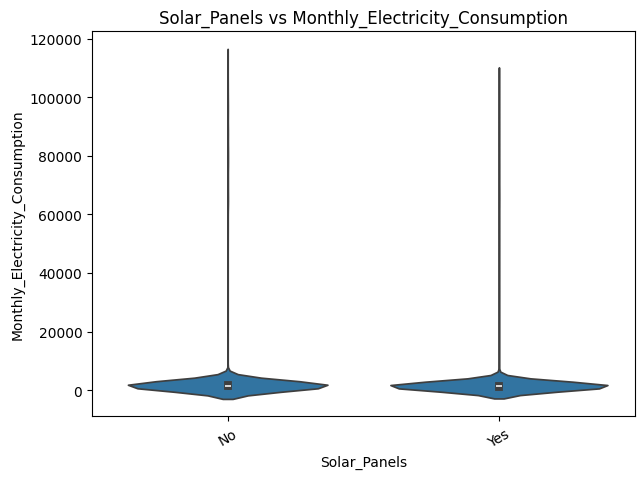

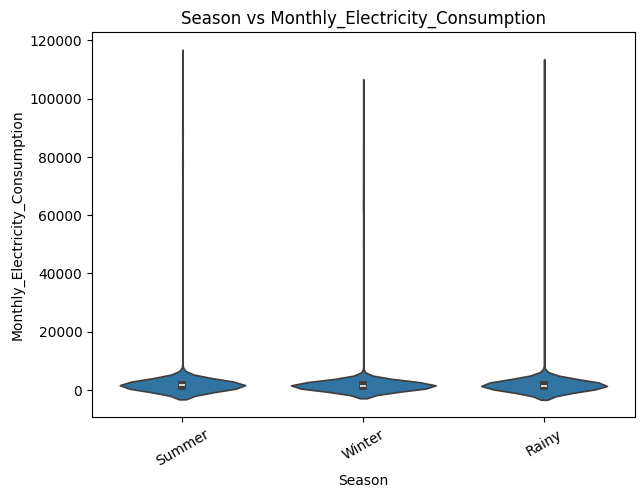

In [28]:
# Violin Plot setiap variabel kategorikal terhadap target

for col in categorical_columns:
    plt.figure(figsize=(7,5))

    sns.violinplot(
        x=col,
        y='Monthly_Electricity_Consumption',
        data=df
    )

    plt.title(f'{col} vs Monthly_Electricity_Consumption')
    plt.xticks(rotation=30)

    plt.show()

##14. Identifikasi Outlier

##14.1 Menghitung Outlier Menggunakan IQR

In [29]:
# Menghitung jumlah outlier menggunakan metode IQR

numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
numerical_columns = numerical_columns.drop('House_ID')

for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col} : {len(outlier)} outlier")

Family_Members : 400 outlier
House_Area_sqft : 335 outlier
Air_Conditioners : 296 outlier
Refrigerators : 389 outlier
Washing_Machines : 244 outlier
Televisions : 364 outlier
Computers : 329 outlier
Water_Heaters : 314 outlier
Ceiling_Fans : 385 outlier
LED_Lights : 396 outlier
Daily_Usage_Hours : 397 outlier
Average_Temperature : 422 outlier
Occupancy_Rate : 390 outlier
Electricity_Tariff : 357 outlier
Monthly_Electricity_Consumption : 474 outlier


##14.2 Boxplot Seluruh Variabel Numerik

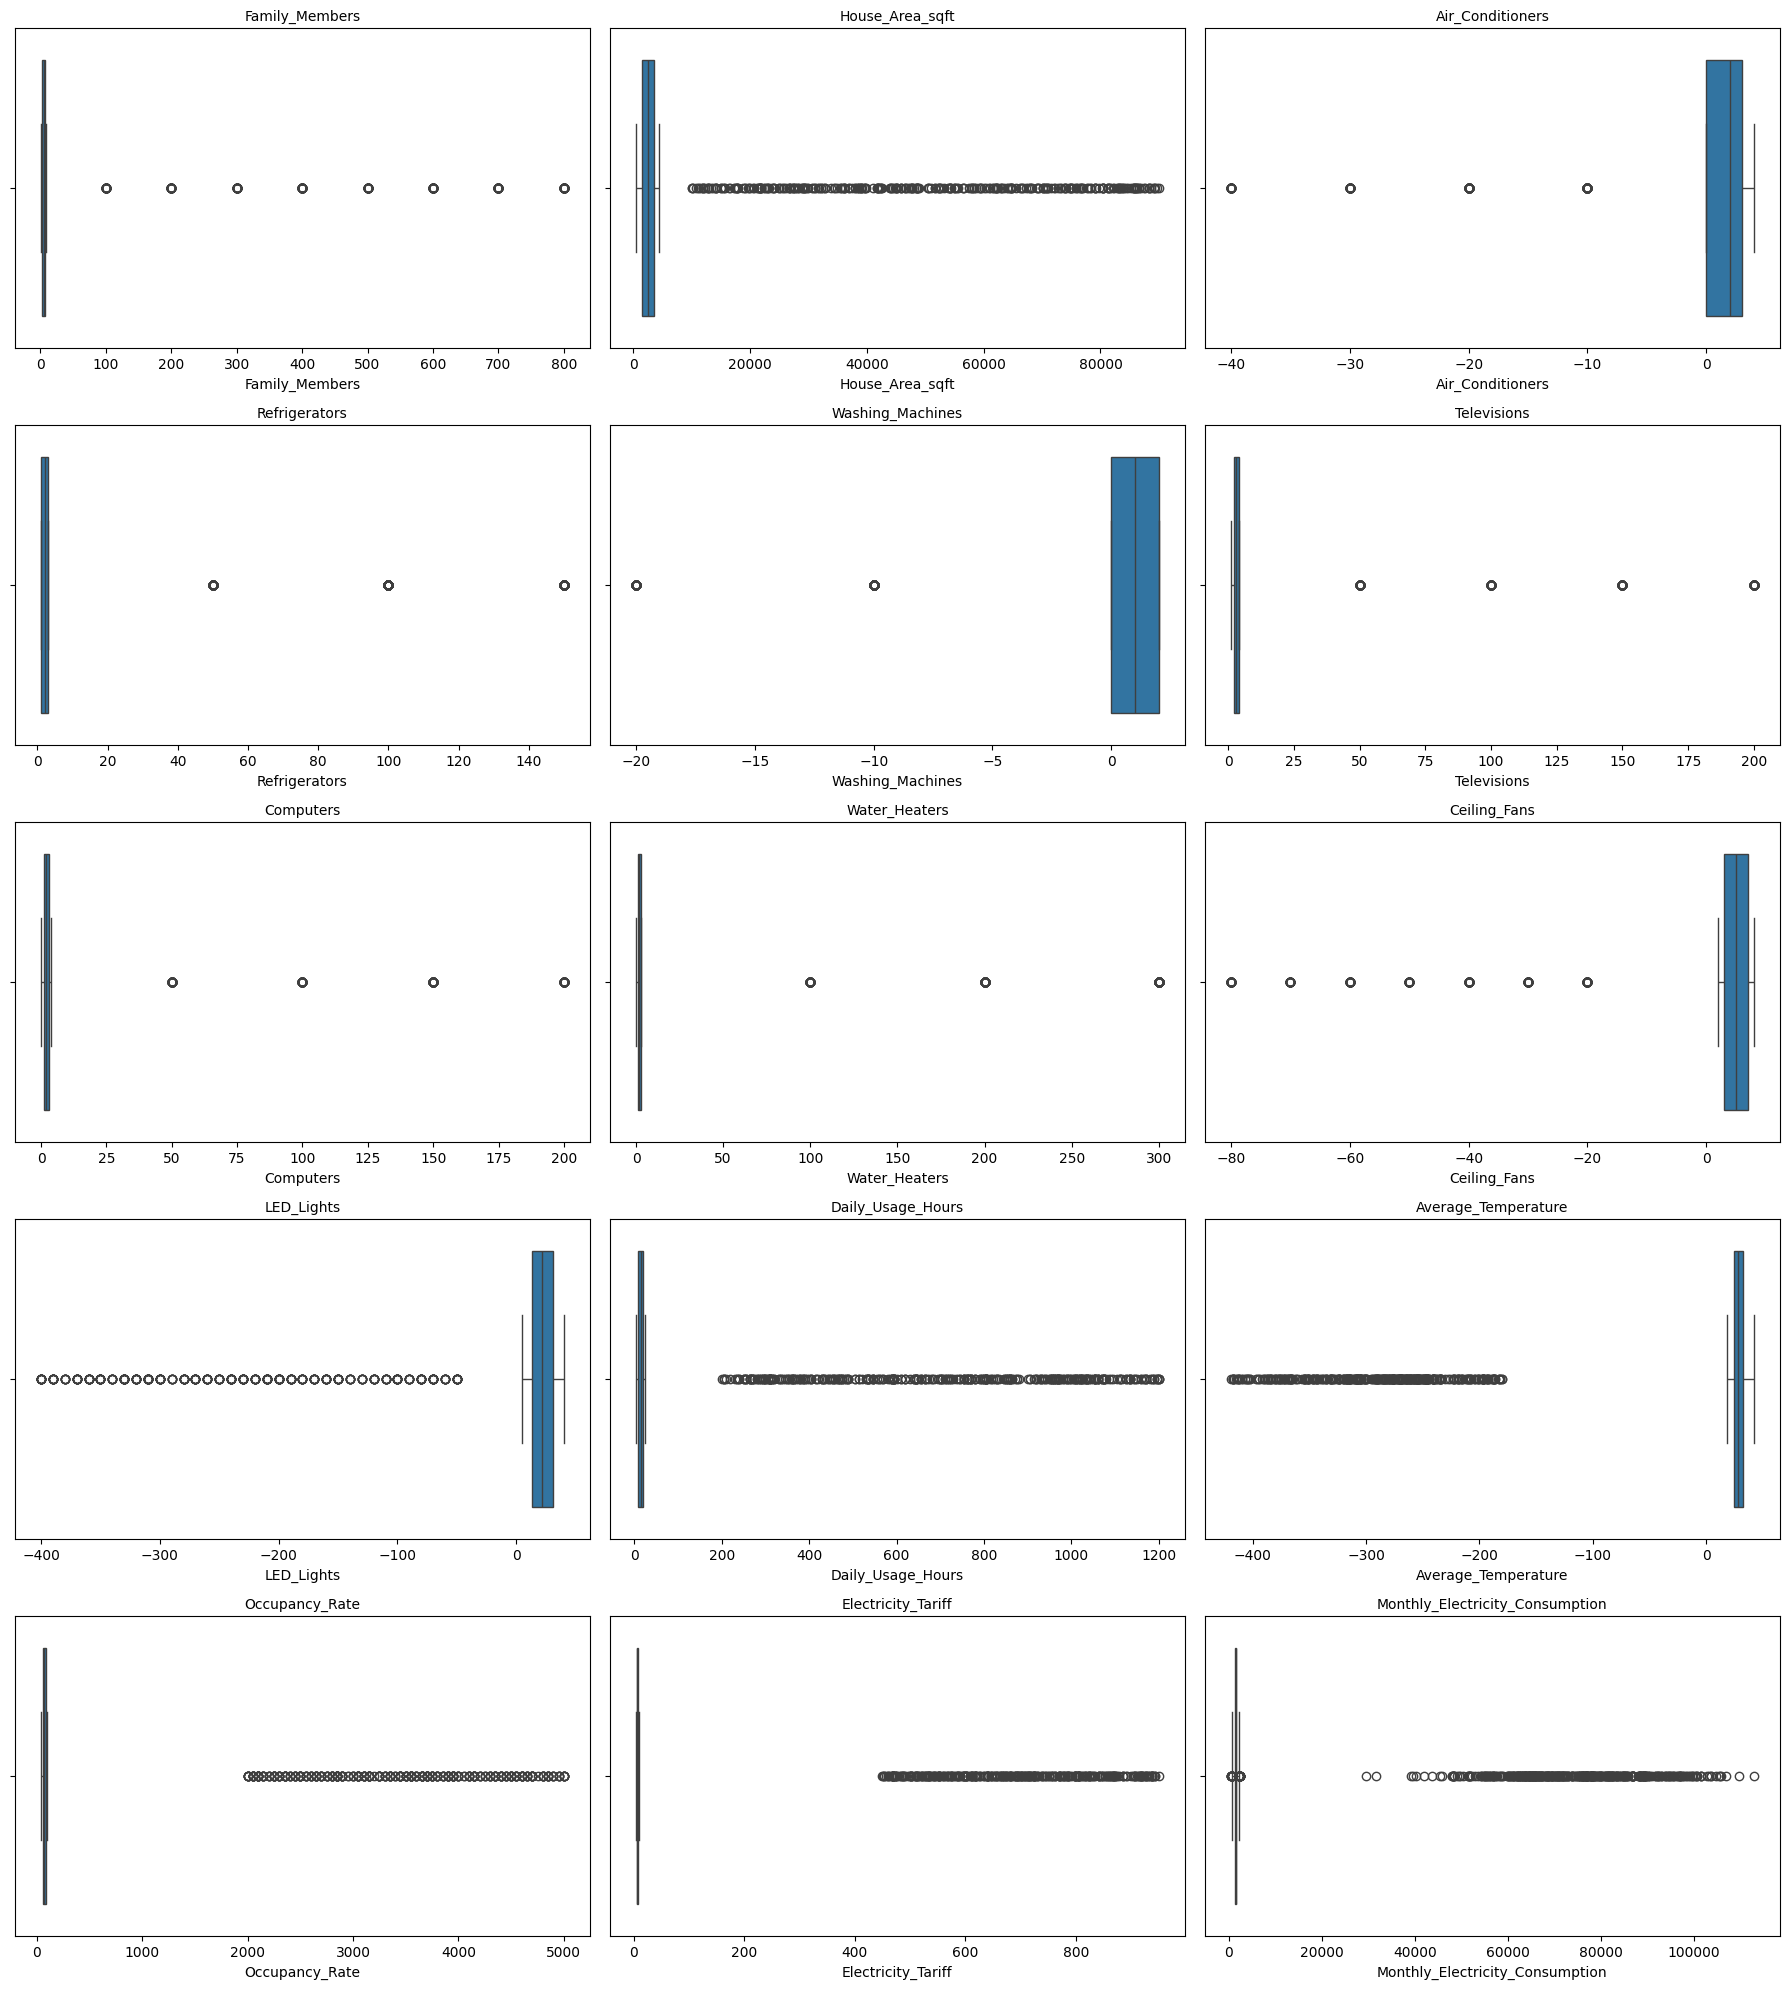

In [30]:
# Boxplot seluruh variabel numerik dalam satu tampilan
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
numerical_columns = numerical_columns.drop('House_ID')

plt.figure(figsize=(18,20))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(5, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col, fontsize=10)

plt.tight_layout()
plt.show()

#3. Data Preparation

##3.1 Membuat Salinan Dataset

In [31]:
df_clean = df.copy()

##3.2 Menghapus Data Duplikat

In [32]:
# Ukuran dataset sebelum menghapus duplikat
print("Ukuran dataset sebelum:", df_clean.shape)

Ukuran dataset sebelum: (21000, 20)


In [33]:
df_clean = df_clean.drop_duplicates()

print(df_clean.shape)

(20000, 20)


##3.3 Menangani Missing Value

##Numerik → Median

In [34]:
numerical_columns = df_clean.select_dtypes(include=['float64','int64']).columns

for col in numerical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

##Kategorikal → Modus

In [35]:
categorical_columns = df_clean.select_dtypes(include='object').columns

for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [36]:
df_clean.isnull().sum()

,0
House_ID,0
House_Type,0
Family_Members,0
House_Area_sqft,0
Air_Conditioners,0
Refrigerators,0
Washing_Machines,0
Televisions,0
Computers,0
Water_Heaters,0


##3.4 Menghapus Kolom yang Tidak Digunakan

In [37]:
# Menghapus kolom House_ID
df_clean = df_clean.drop('House_ID', axis=1)

In [38]:
df_clean.columns

Index(['House_Type', 'Family_Members', 'House_Area_sqft', 'Air_Conditioners',
       'Refrigerators', 'Washing_Machines', 'Televisions', 'Computers',
       'Water_Heaters', 'Ceiling_Fans', 'LED_Lights', 'EV_Charger',
       'Solar_Panels', 'Daily_Usage_Hours', 'Average_Temperature', 'Season',
       'Occupancy_Rate', 'Electricity_Tariff',
       'Monthly_Electricity_Consumption'],
      dtype='object')

##3.5 Memperbaiki Nilai Tidak Valid

##3.5.1 Mengecek Nilai Minimum Sebelum Perbaikan

In [39]:
# Melihat nilai minimum setiap variabel numerik
df_clean.describe().loc['min']

,min
Family_Members,1.00
House_Area_sqft,500.00
Air_Conditioners,-40.00
Refrigerators,1.00
Washing_Machines,-20.00
Televisions,1.00
Computers,0.00
Water_Heaters,0.00
Ceiling_Fans,-80.00
LED_Lights,-400.00


##3.5.2 Memperbaiki Nilai Tidak Valid

In [40]:
# Variabel jumlah perangkat yang tidak boleh bernilai negatif
device_columns = [
    'Air_Conditioners',
    'Washing_Machines',
    'Ceiling_Fans',
    'LED_Lights'
]

# Mengubah nilai negatif menjadi 0
for col in device_columns:
    df_clean[col] = df_clean[col].clip(lower=0)

##3.5.3 Mengecek Nilai Tidak Valid

In [41]:
# Mengecek kembali nilai minimum
df_clean.describe().loc['min']

,min
Family_Members,1.00
House_Area_sqft,500.00
Air_Conditioners,0.00
Refrigerators,1.00
Washing_Machines,0.00
Televisions,1.00
Computers,0.00
Water_Heaters,0.00
Ceiling_Fans,0.00
LED_Lights,0.00


##3.6 Menangani Outlier

##3.6.1 Visualisasi Outlier Sebelum Penanganan

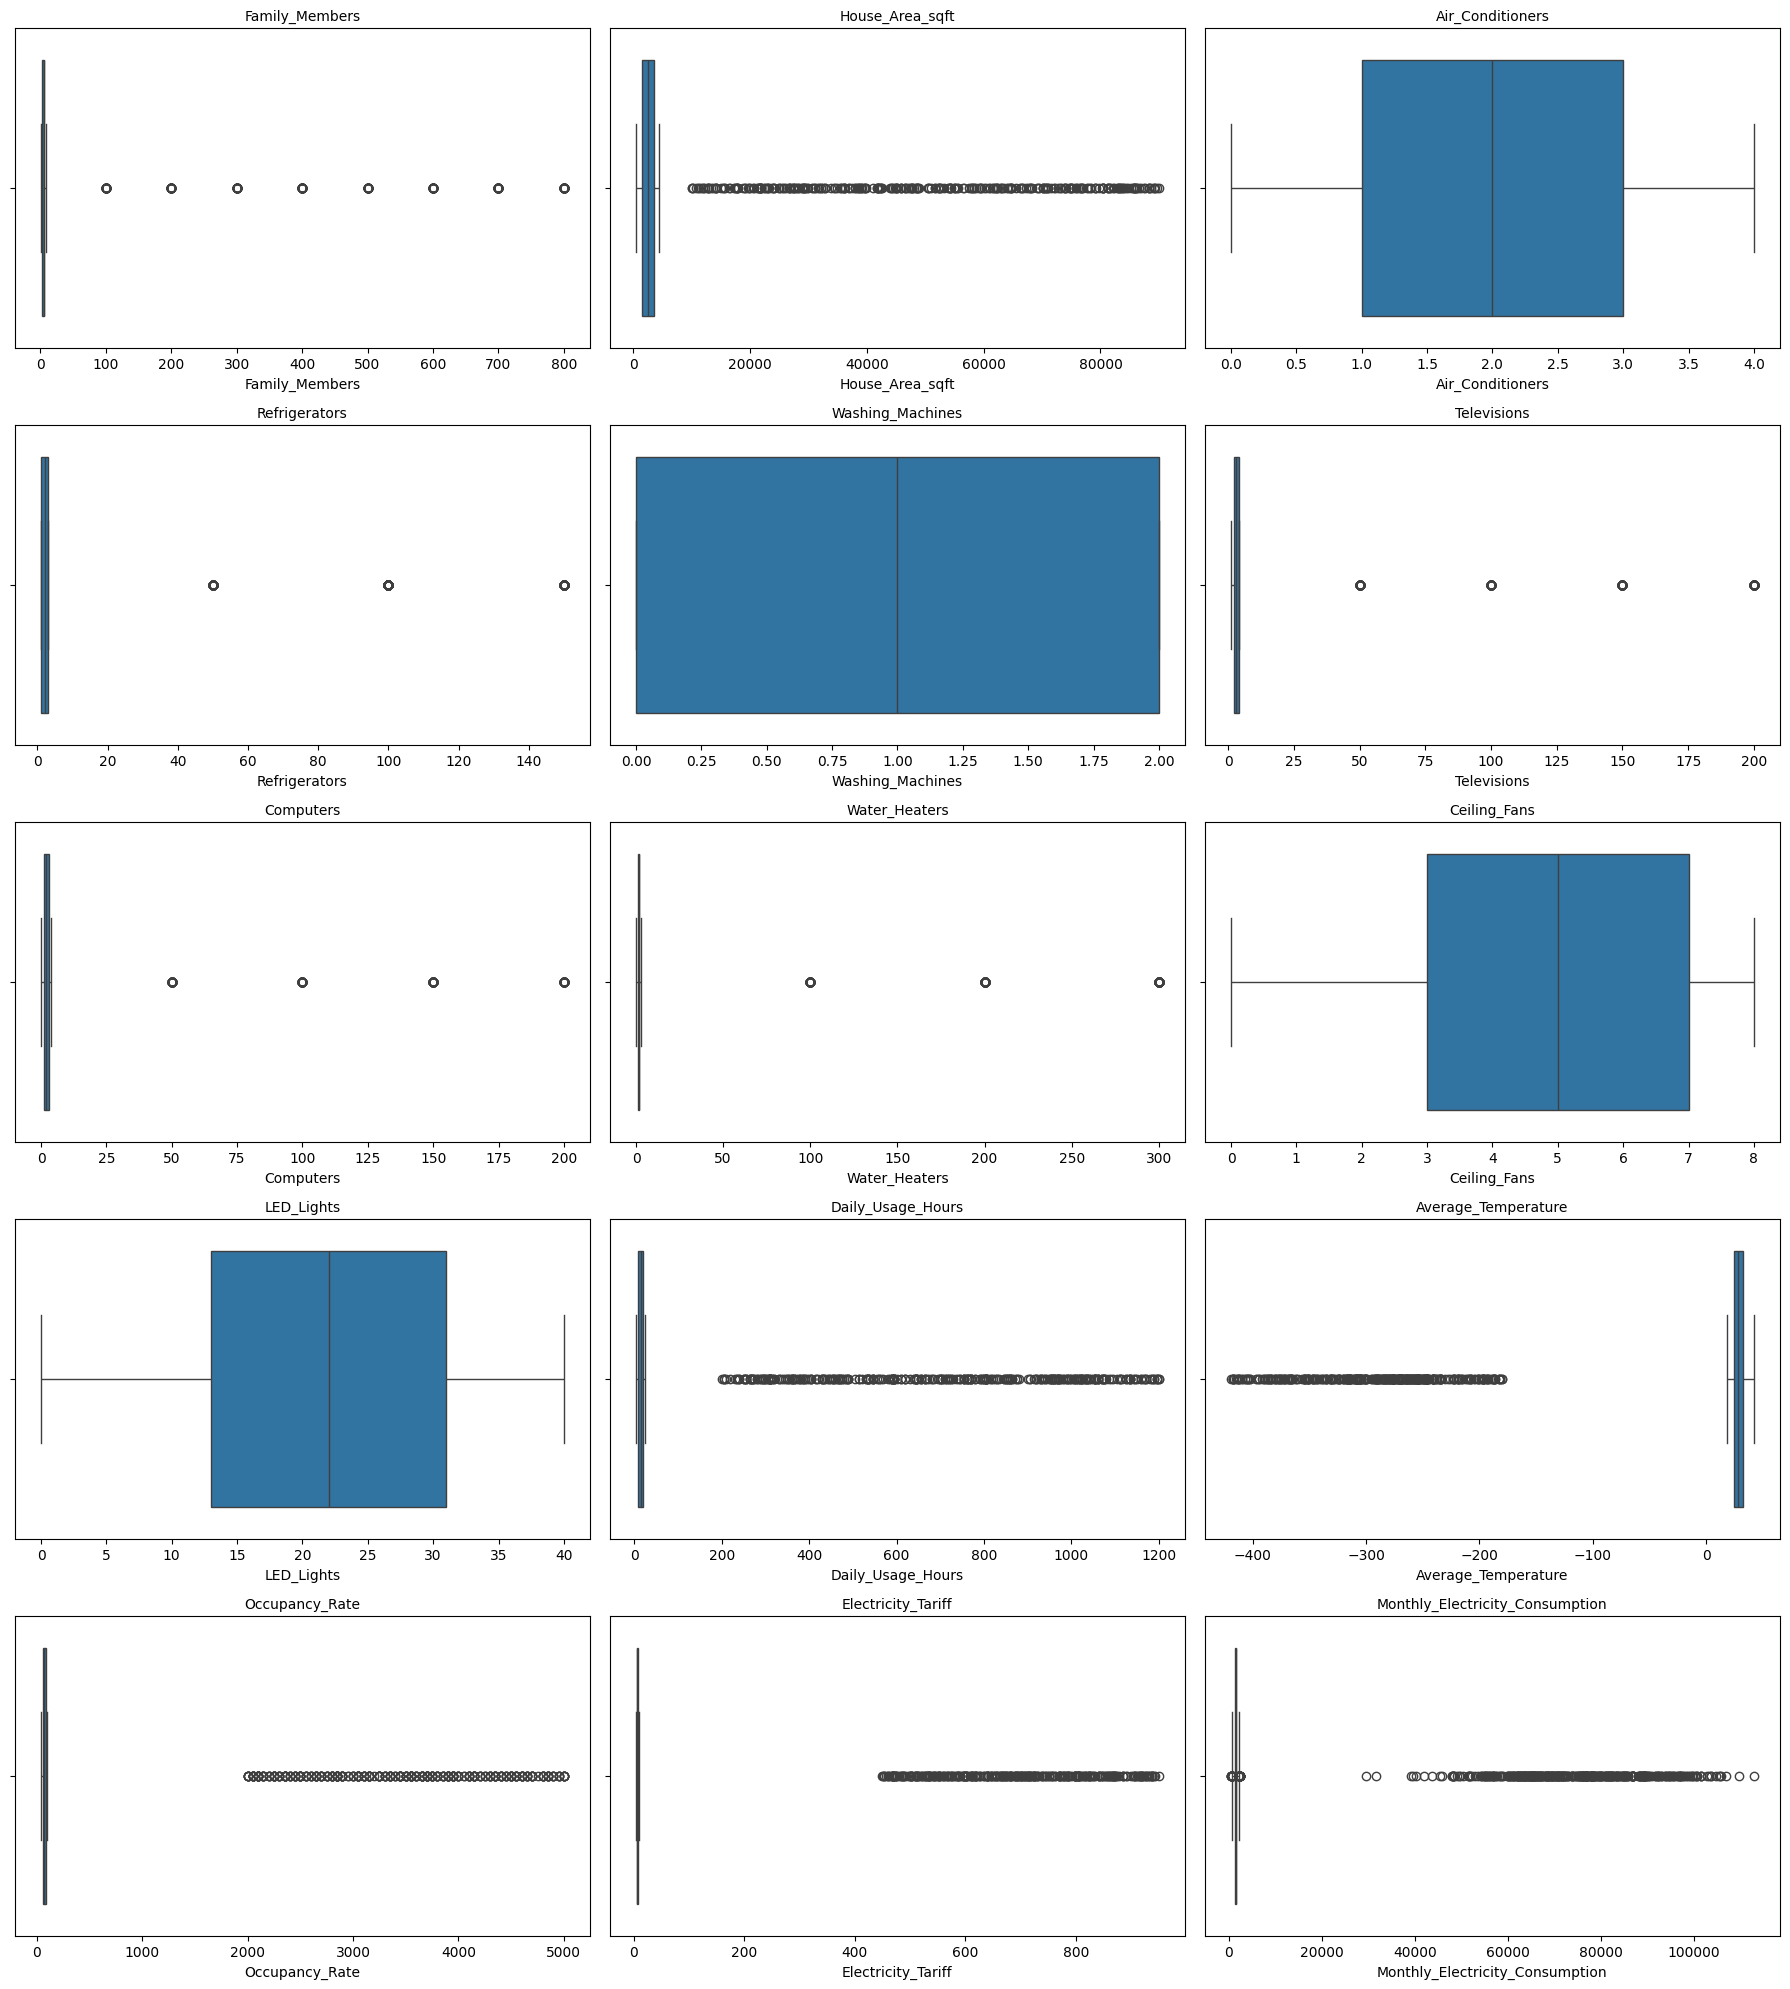

In [42]:
# Memilih variabel numerik
numerical_columns = df_clean.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(18,20))

for i, col in enumerate(numerical_columns, 1):

    plt.subplot(5,3,i)

    sns.boxplot(x=df_clean[col])

    plt.title(col, fontsize=10)

plt.tight_layout()
plt.show()

##3.6.2 Menangani Outlier Menggunakan IQR Capping

In [43]:
# Melakukan capping menggunakan metode IQR

for col in numerical_columns:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

##3.6.3 Visualisasi Setelah Penanganan Outlier

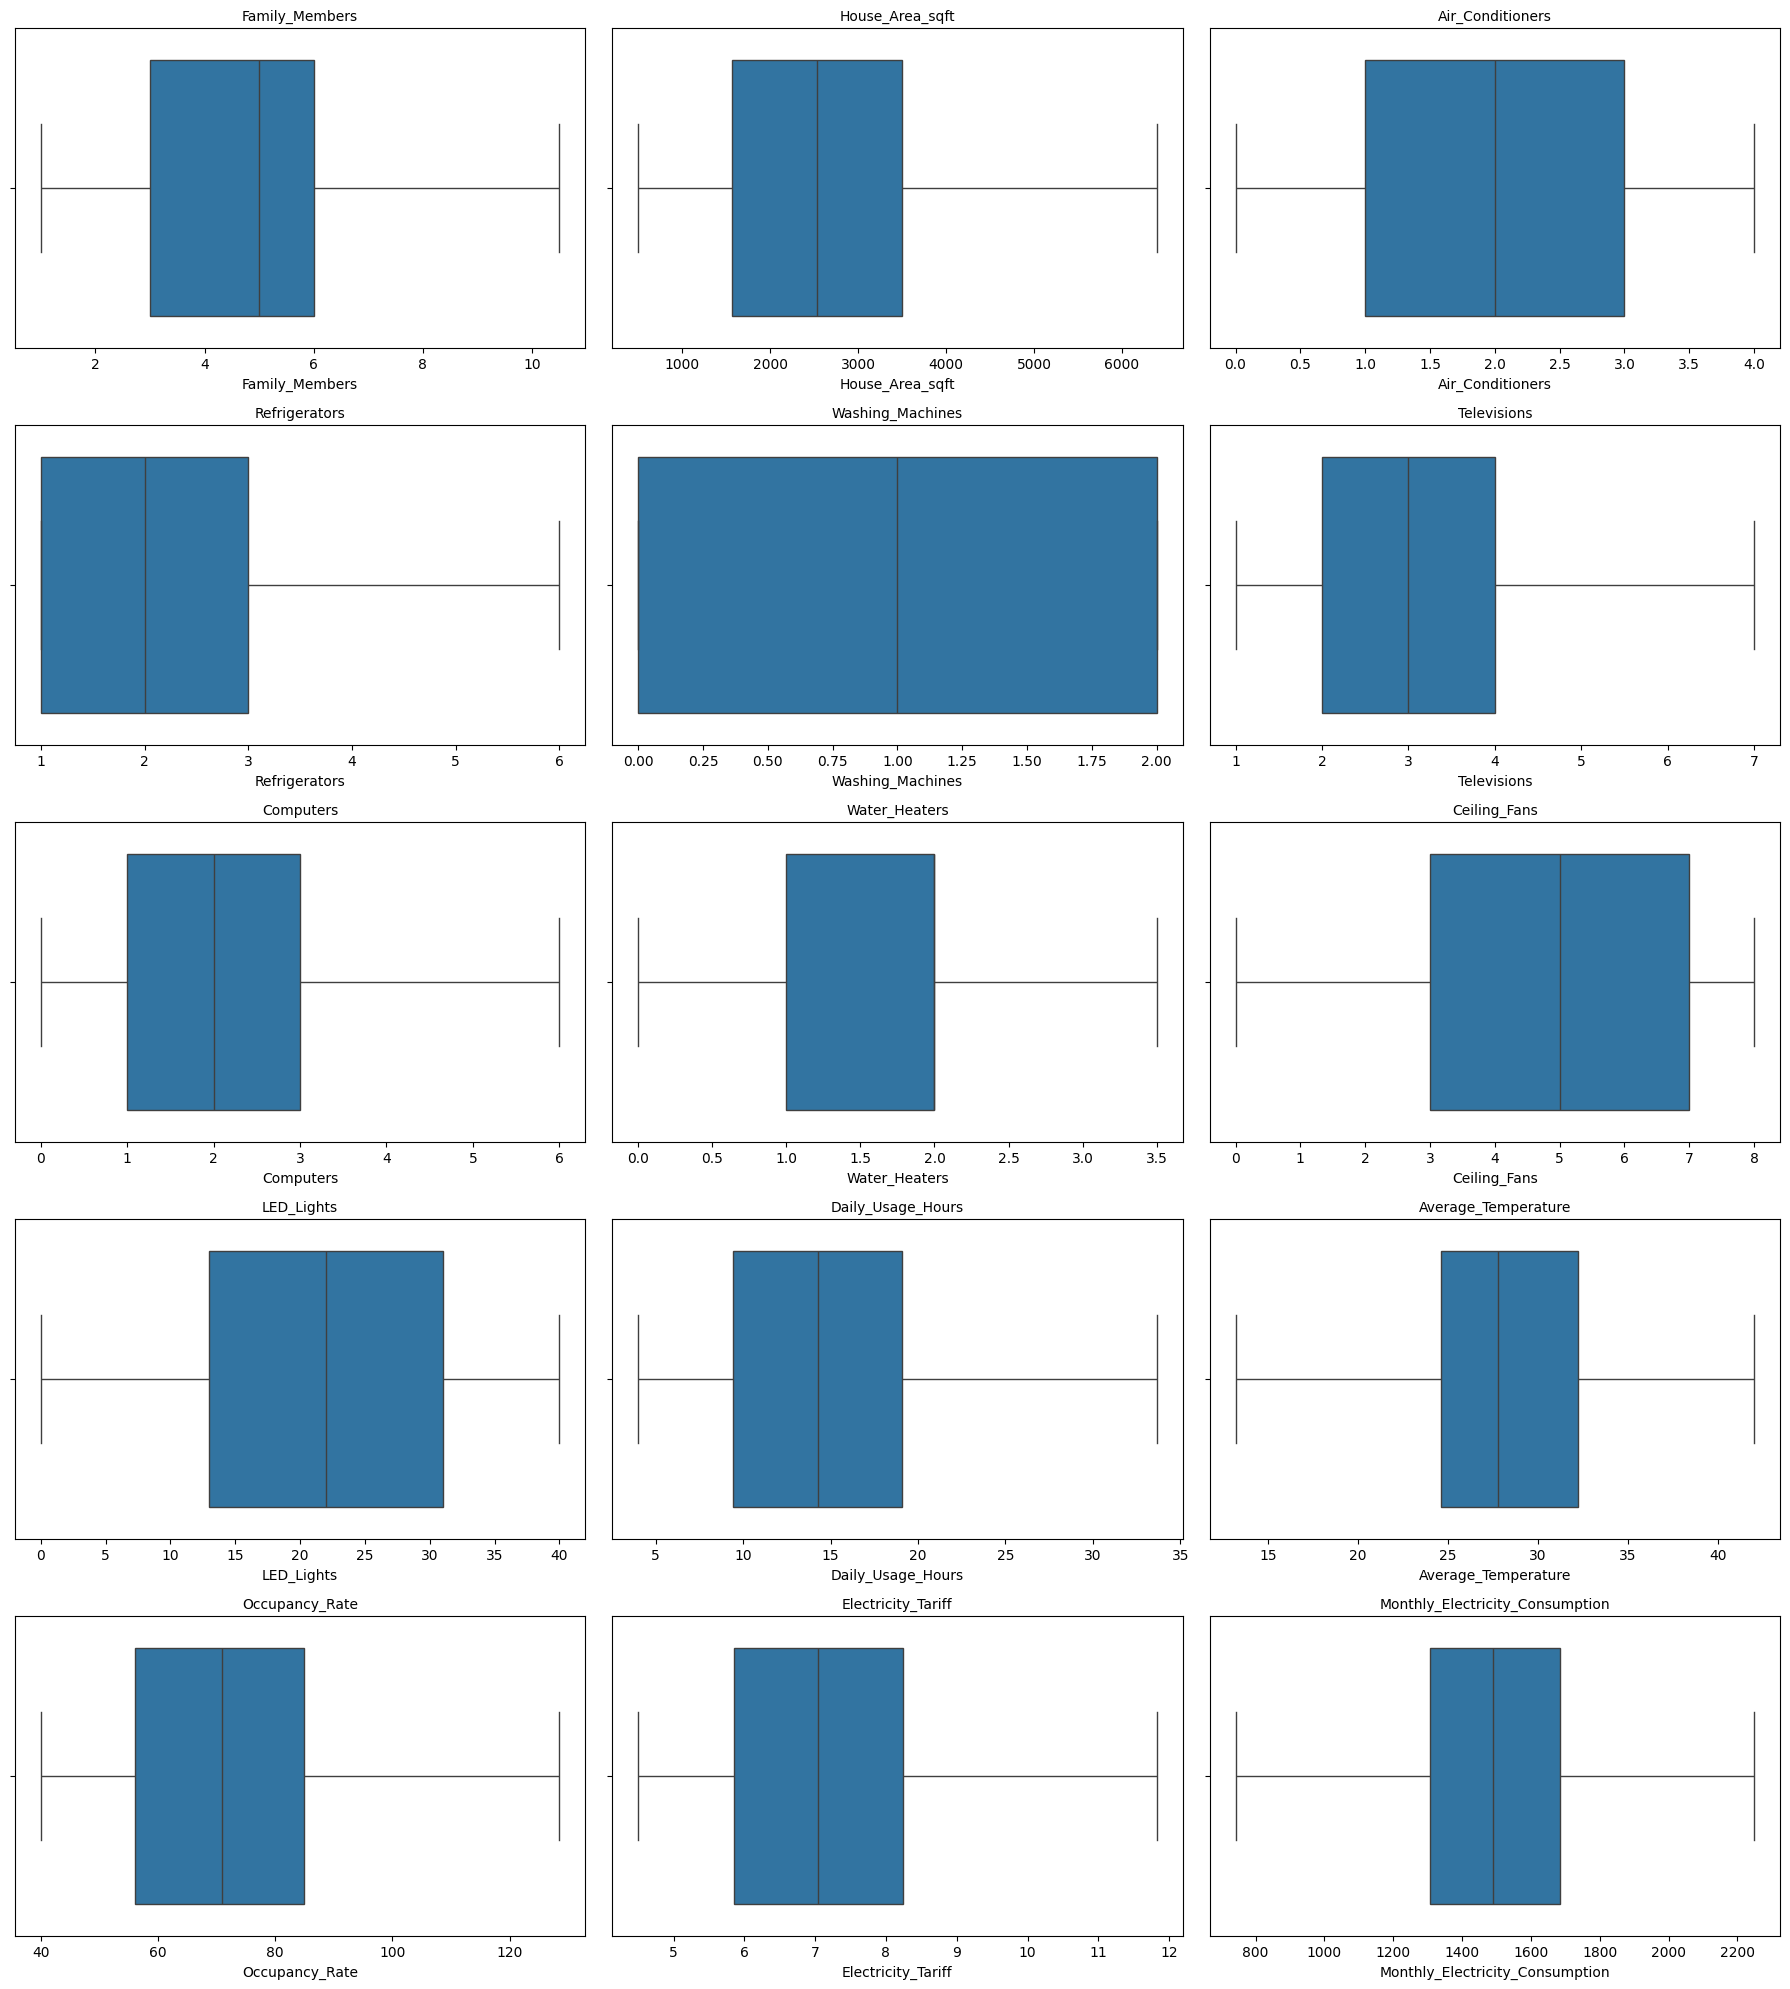

In [44]:
plt.figure(figsize=(18,20))

for i, col in enumerate(numerical_columns, 1):

    plt.subplot(5,3,i)

    sns.boxplot(x=df_clean[col])

    plt.title(col, fontsize=10)

plt.tight_layout()
plt.show()

##3.7 Encoding Variabel Kategorikal

#1. Label Encoding
Mengubah setiap kategori menjadi angka.
##Kapan digunakan?
1. Data ordinal (memiliki urutan)
2. Pendidikan: SMA < S1 < S2 < S3
3. Rating: Low < Medium < High
4. Model berbasis pohon:
Decision Tree
Random Forest
XGBoost
LightGBM
CatBoost
Jangan digunakan jika...

Data bersifat nominal dan modelnya berbasis jarak atau linear karena model bisa menganggap ada hubungan urutan.

#2. One-Hot Encoding (OHE)

Mengubah setiap kategori menjadi kolom baru.
Biasanya menggunakan drop_first=True untuk menghindari multikolinearitas pada model regresi.

##Kapan digunakan?
Data nominal (tidak memiliki urutan)
Linear Regression
Ridge
Lasso
Elastic Net
Logistic Regression
KNN
SVR
Neural Network

##3. Ordinal Encoding
##Kapan digunakan?

Jika memang ada tingkatan.

Contoh:

Kepuasan pelanggan
Pendidikan
Tingkat risiko



##3.7.1 Melihat Variabel Kategorikal

In [45]:
# Menampilkan variabel kategorikal
categorical_columns = df_clean.select_dtypes(include='object').columns

categorical_columns

Index(['House_Type', 'EV_Charger', 'Solar_Panels', 'Season'], dtype='object')

##3.7.2 Melihat Nilai Unik Setiap Kolom

In [46]:
# Menampilkan nilai unik setiap variabel kategorikal

for col in categorical_columns:
    print(f"\n{col}")
    print(df_clean[col].unique())


House_Type
['Apartment' 'Independent' 'Villa']

EV_Charger
['No' 'Yes']

Solar_Panels
['No' 'Yes']

Season
['Summer' 'Winter' 'Rainy']


##3.7.3 Melakukan One-Hot Encoding

In [47]:
# One-Hot Encoding
df_clean = pd.get_dummies(
    df_clean,
    columns=['House_Type',
             'EV_Charger',
             'Solar_Panels',
             'Season'],
    drop_first=True,
    dtype=int
)

##3.7.4 Melihat Hasil Encoding

In [48]:
df_clean.head()

,Family_Members,House_Area_sqft,Air_Conditioners,Refrigerators,Washing_Machines,Televisions,Computers,Water_Heaters,Ceiling_Fans,LED_Lights,...,Average_Temperature,Occupancy_Rate,Electricity_Tariff,Monthly_Electricity_Consumption,House_Type_Independent,House_Type_Villa,EV_Charger_Yes,Solar_Panels_Yes,Season_Summer,Season_Winter
0,2.0,945.0,2.0,2.0,1.0,4.0,1.0,0.0,5.0,18.0,...,27.8,60.0,9.16,1399.00,0,0,0,0,1,0
1,6.0,2959.0,1.0,1.0,2.0,4.0,3.0,2.0,2.0,7.0,...,26.4,93.0,5.26,1310.97,1,0,0,1,0,1
2,6.0,1265.0,4.0,2.0,2.0,7.0,2.0,3.0,0.0,14.0,...,33.6,55.0,6.91,1806.31,0,1,0,0,1,0
3,7.0,2281.0,2.0,3.0,1.0,3.0,0.0,2.0,8.0,38.0,...,25.9,65.0,6.66,1490.51,1,0,1,0,0,1
4,1.0,857.0,1.0,3.0,1.0,4.0,3.0,0.0,8.0,8.0,...,37.1,80.0,7.49,1222.93,1,0,0,1,0,1


##3.8 Memisahkan Fitur dan Target

##3.8.1 Menentukan Variabel Target (y) Variabel Fitur (X)

In [49]:
# Menentukan variabel target
y = df_clean['Monthly_Electricity_Consumption']
# Menentukan variabel fitur
X = df_clean.drop('Monthly_Electricity_Consumption', axis=1)

##3.8.2 Melihat Dimensi Fitur dan Target

In [50]:
print("Bentuk data fitur (X):", X.shape)
print("Bentuk data target (y):", y.shape)

Bentuk data fitur (X): (20000, 20)
Bentuk data target (y): (20000,)


##3.9 Train Test Split

##3.9.1 Import Library

In [51]:
from sklearn.model_selection import train_test_split

##3.9.2 Membagi Dataset

In [52]:
# Membagi data menjadi 80% data latih dan 20% data uji
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

##3.9.3 Melihat Ukuran Data

In [53]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (16000, 20)
X_test  : (4000, 20)
y_train : (16000,)
y_test  : (4000,)


##3.10 Feature Scaling

##3.10.1 Import Library

In [54]:
from sklearn.preprocessing import StandardScaler

##3.10.2 Membuat Objek StandardScaler dan Melakukan Standardisasi Data

In [55]:
# Membuat objek StandardScaler
scaler = StandardScaler()

# Standardisasi data latih
X_train_scaled = scaler.fit_transform(X_train)

# Standardisasi data uji
X_test_scaled = scaler.transform(X_test)

##3.10.3 Memeriksa Bentuk Data Setelah Scaling

In [56]:
print("X_train_scaled :", X_train_scaled.shape)
print("X_test_scaled  :", X_test_scaled.shape)

X_train_scaled : (16000, 20)
X_test_scaled  : (4000, 20)


##3.10.4 Melihat Sebagian Hasil Scaling

In [57]:
# Menampilkan 5 baris pertama hasil scaling
pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
).head()

,Family_Members,House_Area_sqft,Air_Conditioners,Refrigerators,Washing_Machines,Televisions,Computers,Water_Heaters,Ceiling_Fans,LED_Lights,Daily_Usage_Hours,Average_Temperature,Occupancy_Rate,Electricity_Tariff,House_Type_Independent,House_Type_Villa,EV_Charger_Yes,Solar_Panels_Yes,Season_Summer,Season_Winter
0,-1.550294,-0.853519,-1.268009,-1.126579,1.274274,-1.287932,0.645524,-1.389768,-0.438539,-0.479695,1.489149,1.758819,-0.914746,1.081978,1.469119,-0.766253,-1.063914,0.951786,1.480225,-0.766973
1,1.441623,1.017664,0.262305,0.967434,-1.225375,-1.287932,-0.723199,-0.489112,-0.438539,1.531355,0.060266,-0.686673,-1.290438,0.170627,-0.680680,-0.766253,-1.063914,0.951786,-0.675573,-0.766973
2,1.441623,-1.307634,-1.268009,-1.126579,1.274274,-0.480641,-1.407560,-0.489112,-0.438539,-0.766988,1.440437,0.512098,-0.700065,-0.027493,-0.680680,1.305051,0.939926,-1.050656,1.480225,-0.766973
3,0.586790,-0.861686,1.027463,-1.126579,-1.225375,1.133941,-0.038837,0.411543,-0.438539,0.094890,1.440437,0.272344,-0.163362,-1.480373,1.469119,-0.766253,0.939926,-1.050656,-0.675573,-0.766973
4,0.159373,0.936806,-1.268009,-0.079572,-1.225375,3.555815,0.645524,1.312199,0.051688,-1.150046,0.985792,0.016606,-1.397779,-1.209609,1.469119,-0.766253,-1.063914,-1.050656,-0.675573,-0.766973


#4 Modeling

##4.1 Import Library

In [58]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR

##4.2 Membangun Model

In [59]:
# Membuat model
lr_model = LinearRegression()

ridge_model = Ridge()

lasso_model = Lasso()

svr_model = SVR()

##4.3 Melatih Model

In [60]:
# Training model
lr_model.fit(X_train_scaled, y_train)

ridge_model.fit(X_train_scaled, y_train)

lasso_model.fit(X_train_scaled, y_train)

svr_model.fit(X_train_scaled, y_train)

SVR()

##4.4 Melakukan Prediksi

In [61]:
# Prediksi data uji
y_pred_lr = lr_model.predict(X_test_scaled)

y_pred_ridge = ridge_model.predict(X_test_scaled)

y_pred_lasso = lasso_model.predict(X_test_scaled)

y_pred_svr = svr_model.predict(X_test_scaled)

##4.5 Melihat Hasil Prediksi

In [62]:
hasil_prediksi = pd.DataFrame({
    'Actual': y_test.values,
    'Linear Regression': y_pred_lr,
    'Ridge Regression': y_pred_ridge,
    'Lasso Regression': y_pred_lasso,
    'SVR': y_pred_svr
})

hasil_prediksi.head()

,Actual,Linear Regression,Ridge Regression,Lasso Regression,SVR
0,1694.92,1614.926537,1614.915864,1616.129919,1542.178960
1,1443.95,1466.560154,1466.562307,1467.980573,1473.999726
2,1620.35,1585.609018,1585.607717,1578.578901,1553.695495
3,1490.51,1913.270315,1913.246175,1905.995550,1695.654339
4,1464.60,1432.254480,1432.261762,1432.187054,1458.530509


#5 Evaluation

##5.1 Import Library

In [63]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

##5.2 Menghitung Nilai Evaluasi

In [64]:
# Membuat tabel evaluasi

hasil_evaluasi = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'SVR'],

    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso),
        mean_absolute_error(y_test, y_pred_svr)
    ],

    'MSE': [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso),
        mean_squared_error(y_test, y_pred_svr)
    ],

    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_test, y_pred_svr))
    ],

    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_svr)
    ]
})

hasil_evaluasi

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,96.022539,25493.456316,159.666704,0.700969
1,Ridge Regression,96.026842,25493.573965,159.667072,0.700967
2,Lasso Regression,96.919881,25547.653007,159.836332,0.700333
3,SVR,139.121853,36786.744699,191.798709,0.568501


##Empat metrik digunakan untuk mengevaluasi performa model:

##1. **MAE (Mean Absolute Error)**: Mengukur rata-rata selisih absolut antara nilai aktual dan prediksi. Semakin kecil nilainya, semakin baik model.
##2. **MSE (Mean Squared Error)**: Mengukur rata-rata kuadrat kesalahan prediksi. Nilai yang lebih kecil menunjukkan performa yang lebih baik.
##3. **RMSE (Root Mean Squared Error)**: Akar dari MSE yang memiliki satuan sama dengan target sehingga lebih mudah diinterpretasikan.
##4. **R² Score**: Mengukur kemampuan model dalam menjelaskan variasi data. Nilai yang semakin mendekati 1 menunjukkan performa model yang semakin baik.

##5.3 Menentukan Model Terbaik

In [65]:
hasil_evaluasi.sort_values(by='R2 Score', ascending=False)

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,96.022539,25493.456316,159.666704,0.700969
1,Ridge Regression,96.026842,25493.573965,159.667072,0.700967
2,Lasso Regression,96.919881,25547.653007,159.836332,0.700333
3,SVR,139.121853,36786.744699,191.798709,0.568501


##5.4 Visualisasi Perbandingan Model

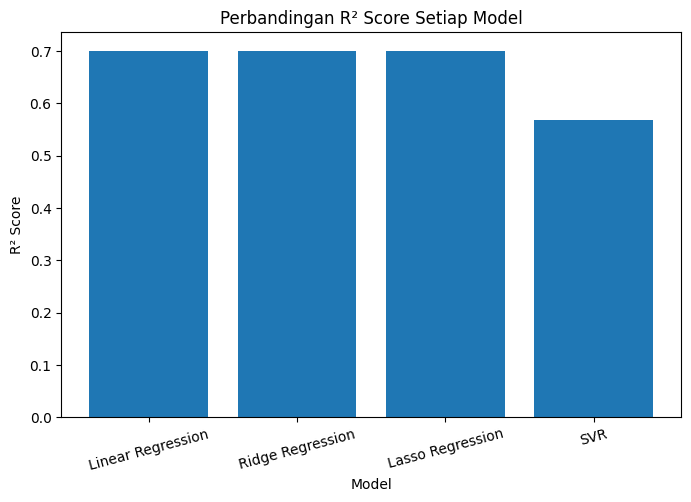

In [66]:
plt.figure(figsize=(8,5))

plt.bar(hasil_evaluasi['Model'], hasil_evaluasi['R2 Score'])

plt.title('Perbandingan R² Score Setiap Model')
plt.xlabel('Model')
plt.ylabel('R² Score')

plt.xticks(rotation=15)

plt.show()

##**Interpretasi**

##Berdasarkan hasil evaluasi menggunakan metrik Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), dan R² Score, diperoleh bahwa Linear Regression memberikan performa terbaik dibandingkan model lainnya. Model ini memiliki nilai MAE, MSE, dan RMSE paling rendah serta nilai R² Score paling tinggi, yaitu 0,700969. Hal ini menunjukkan bahwa sekitar 70,10% variasi konsumsi listrik bulanan dapat dijelaskan oleh model.

##Ridge Regression menghasilkan performa yang hampir identik dengan Linear Regression. Hal ini menunjukkan bahwa regularisasi L2 tidak memberikan peningkatan yang signifikan pada dataset ini.

##Lasso Regression juga memberikan hasil yang cukup baik, namun memiliki nilai error sedikit lebih tinggi dan nilai R² Score sedikit lebih rendah dibandingkan Linear Regression dan Ridge Regression.

##Sementara itu, Support Vector Regression (SVR) menghasilkan performa terendah dengan nilai MAE, MSE, dan RMSE yang paling besar serta R² Score sebesar 0,568501. Hal ini mengindikasikan bahwa konfigurasi SVR yang digunakan belum mampu menangkap pola data sebaik model regresi linear.

##**Kesimpulan**

##Berdasarkan hasil evaluasi, Linear Regression merupakan model terbaik untuk memprediksi Monthly Electricity Consumption pada dataset ini. Model tersebut menghasilkan MAE sebesar 96,02, RMSE sebesar 159,67, dan R² Score sebesar 0,700969, sehingga dipilih sebagai model akhir karena memiliki tingkat kesalahan paling rendah dan kemampuan prediksi terbaik dibandingkan model lainnya.

,Model,R2 Train,R2 Test
0,Linear Regression,0.667537,0.700969
1,Ridge Regression,0.667537,0.700967
2,Lasso Regression,0.667315,0.700333
3,SVR,0.545960,0.568501


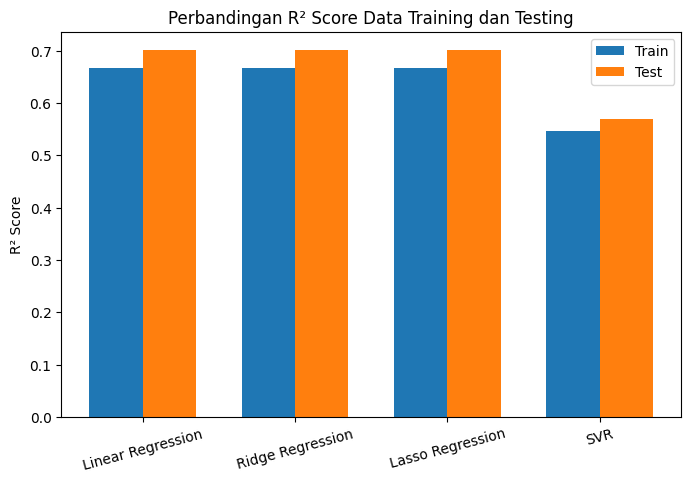

In [67]:
# Menghitung R² Train dan Test
hasil_fit = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'SVR'],
    'R2 Train': [
        r2_score(y_train, lr_model.predict(X_train_scaled)),
        r2_score(y_train, ridge_model.predict(X_train_scaled)),
        r2_score(y_train, lasso_model.predict(X_train_scaled)),
        r2_score(y_train, svr_model.predict(X_train_scaled))
    ],
    'R2 Test': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_svr)
    ]
})

# Menampilkan tabel
display(hasil_fit)

# Visualisasi
plt.figure(figsize=(8,5))

x = range(len(hasil_fit))
width = 0.35

plt.bar([i - width/2 for i in x], hasil_fit['R2 Train'], width=width, label='Train')
plt.bar([i + width/2 for i in x], hasil_fit['R2 Test'], width=width, label='Test')

plt.xticks(x, hasil_fit['Model'], rotation=15)
plt.ylabel('R² Score')
plt.title('Perbandingan R² Score Data Training dan Testing')
plt.legend()

plt.show()

##**Interpretasi**
*   Jika tinggi batang Train dan Test hampir sama, maka model tidak mengalami overfitting.
*   Jika batang Train jauh lebih tinggi dibandingkan Test, maka model mengalami overfitting.
*   Jika kedua batang sama-sama rendah, maka model mengalami underfitting.



In [68]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title):

    train_sizes, train_scores, test_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        cv=5,
        scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    test_mean = test_scores.mean(axis=1)

    plt.figure(figsize=(7,5))

    plt.plot(train_sizes, train_mean,
             marker='o',
             label='Training Score')

    plt.plot(train_sizes, test_mean,
             marker='o',
             label='Validation Score')

    plt.title(title)
    plt.xlabel("Jumlah Data Training")
    plt.ylabel("R² Score")
    plt.legend()
    plt.grid(True)

    plt.show()

##Menampilkan Learning Curve

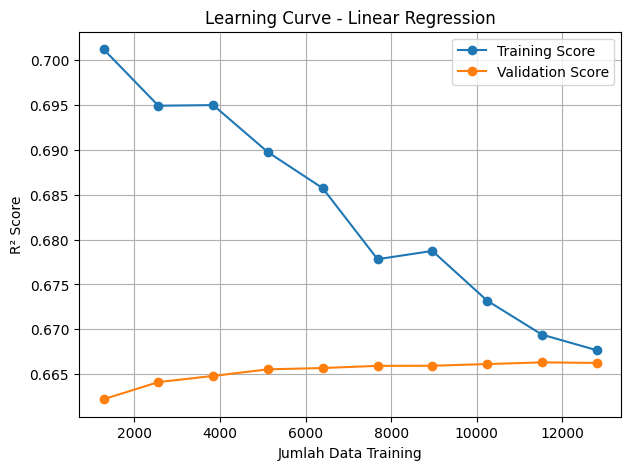

In [69]:
plot_learning_curve(
    lr_model,
    X_train_scaled,
    y_train,
    "Learning Curve - Linear Regression"
)

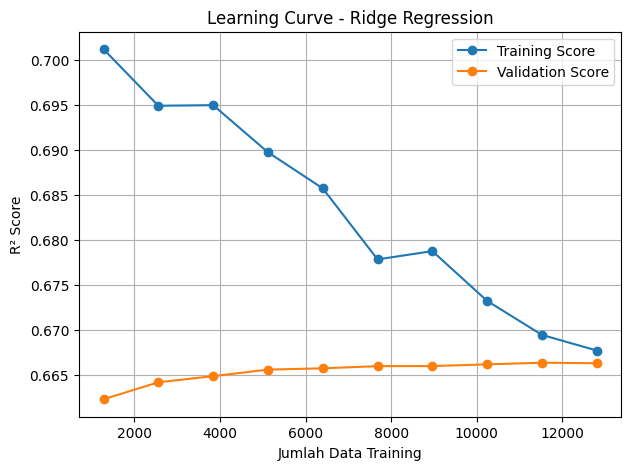

In [70]:
plot_learning_curve(
    ridge_model,
    X_train_scaled,
    y_train,
    "Learning Curve - Ridge Regression"
)

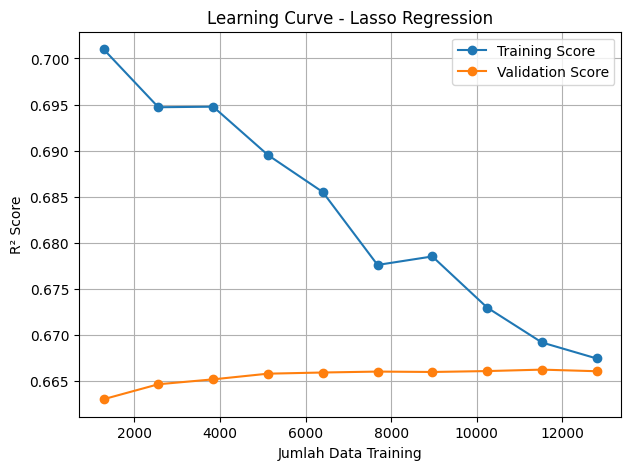

In [71]:
plot_learning_curve(
    lasso_model,
    X_train_scaled,
    y_train,
    "Learning Curve - Lasso Regression"
)

##Analisis
##1. Linear Regression ✅ Good Fit
1. Training Score dimulai sekitar 0,70 lalu turun hingga 0,667.
2. Validation Score naik dari sekitar 0,662 menjadi 0,666.
3. Di bagian akhir, kedua kurva hampir bertemu.

##Interpretasi:

1. Tidak terjadi overfitting.
2. Selisih train dan validation sangat kecil (sekitar 0,001–0,003 di akhir).
3. Model sudah cukup stabil (good fit).

##2. Ridge Regression ✅ Good Fit
1. Polanya hampir sama dengan Linear Regression.
2. Training Score menurun secara bertahap.
3. Validation Score meningkat dan stabil.
4. Kedua kurva juga hampir bertemu.
##Interpretasi:
1. Tidak terdapat overfitting.
2. Regularisasi Ridge membuat model tetap stabil.
3. Generalisasi model terhadap data baru cukup baik.

##3. Lasso Regression ✅ Good Fit
1. Kurva hampir identik dengan Ridge Regression.
2. Training Score menurun.
3. Validation Score meningkat sedikit demi sedikit.
4. Gap di akhir sangat kecil.

##Interpretasi:
1. Tidak terjadi overfitting.
2. Tidak menunjukkan underfitting yang berarti.
3. Model memiliki kemampuan generalisasi yang baik.

##Kesimpulan
Ketiga model menunjukkan karakteristik good fit, yaitu:
1. Tidak ada jarak yang besar antara Training Score dan Validation Score pada akhir kurva.
2. Semakin banyak data yang digunakan, kedua kurva semakin mendekat dan stabil.
3. Tidak terlihat pola di mana Training Score sangat tinggi tetapi Validation Score tetap rendah (yang merupakan ciri overfitting).

#6. Deployment

##6.1 Import Library

In [90]:
import joblib

##6.2 Menyimpan Model

In [91]:
joblib.dump(lr_model, "linear_regression_model.pkl")

['linear_regression_model.pkl']

##6.3 Menyimpan StandardScaler

In [92]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

##6.4 Menyimpan Nama Fitur

In [93]:
feature_names = X.columns.tolist()

joblib.dump(feature_names, "feature_names.pkl")

['feature_names.pkl']

##6.5 Memuat Kembali Model

In [94]:
model = joblib.load("linear_regression_model.pkl")
scaler = joblib.load("scaler.pkl")
feature_names = joblib.load("feature_names.pkl")

##6.6 Uji Coba Model

In [96]:
sample = X_test.iloc[[0]]

sample

,Family_Members,House_Area_sqft,Air_Conditioners,Refrigerators,Washing_Machines,Televisions,Computers,Water_Heaters,Ceiling_Fans,LED_Lights,Daily_Usage_Hours,Average_Temperature,Occupancy_Rate,Electricity_Tariff,House_Type_Independent,House_Type_Villa,EV_Charger_Yes,Solar_Panels_Yes,Season_Summer,Season_Winter
11089,8.0,1674.0,2.0,2.0,0.0,3.0,3.0,3.0,0.0,38.0,10.1,32.8,71.0,7.87,0,0,0,0,1,0


In [97]:
sample_scaled = scaler.transform(sample)

In [98]:
prediction = model.predict(sample_scaled)

prediction

array([1614.92653735])

##Bandingkan Dengan Nilai Aktual

In [99]:
actual = y_test.iloc[0]

print("Nilai Aktual   :", actual)
print("Hasil Prediksi :", prediction[0])

Nilai Aktual   : 1694.92
Hasil Prediksi : 1614.926537345147


In [100]:
hasil = pd.DataFrame({
    "Actual": [actual],
    "Prediction": [prediction[0]],
    "Error": [abs(actual - prediction[0])]
})

hasil

,Actual,Prediction,Error
0,1694.92,1614.926537,79.993463


In [101]:
sample = X_test.iloc[:10]

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)

hasil = pd.DataFrame({
    "Actual": y_test.iloc[:10].values,
    "Prediction": prediction
})

hasil["Error"] = abs(hasil["Actual"] - hasil["Prediction"])

hasil

,Actual,Prediction,Error
0,1694.92,1614.926537,79.993463
1,1443.95,1466.560154,22.610154
2,1620.35,1585.609018,34.740982
3,1490.51,1913.270315,422.760315
4,1464.60,1432.254480,32.345520
5,2034.75,2055.869995,21.119995
6,1631.25,1543.726022,87.523978
7,1994.84,1903.038496,91.801504
8,1711.06,1314.496021,396.563979
9,1138.84,1313.279087,174.439087


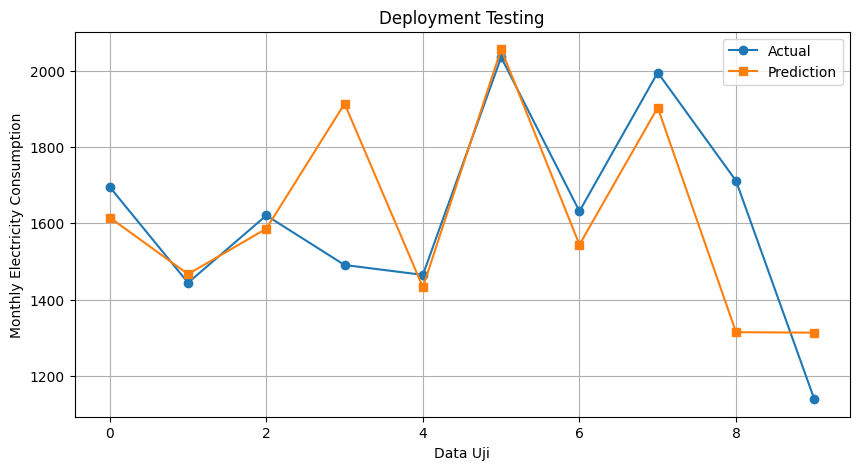

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(hasil["Actual"], marker='o', label='Actual')
plt.plot(hasil["Prediction"], marker='s', label='Prediction')

plt.title("Deployment Testing")
plt.xlabel("Data Uji")
plt.ylabel("Monthly Electricity Consumption")
plt.legend()

plt.grid(True)

plt.show()